## ДЗ 1.
# Анализ и очистка данных.

**Цель**
* формирование практических навыков:
    - переноса данных в среду фреймвока анализа,
    - проведения первичного анализа признаков и объектов,
    - оценки чистоты и полноты данных, определения основных статистических характеристик данных,
    - проведения процедуры очистки данных от выбросов,
    - проведение процедуры заполнения пропусков,
    - проведение анализа связи признаков с целевым свойством,
    - проведения селекции признаков на основе фильтрации,
    - генерация линейной модели  
    - формирования отчета.

* **Задачи**:
    - выполнить загрузку всех составляющих данных,
    - определить список предикторов и целевой признак,
    - определить типы признаков и провести оценку их полноты,
    - оценить сбалансированность данных по целевому признаку,
    - определить класс задачи и провести очистку данных и операцию заполнения пробелов,
    - провести анализ связей признаков с целью и установить факты мультиколлинеарности признаков,
    - провести селекцию признаков.
    - По результатам анализа сделать выводы о составе и качестве данных и реализовать пайплайн первичной обработки данных.
    - Собрать линейную регрессионную ли классификационную модель
    
* **Среда анализа** python-sklearn-scipy

*  [Практическая часть](#practice)
    * [Загрузка данных](#load_data)
    * [Приведение типов](#cast)
    * [Обзор данных](#review)    
    * [Обработка пропусков](#gaps)
    * [Обработка выбросов](#outliers)
    * [Построение новых признаков](#new_features)
    * [Сохранение обучающего датасета](#saving)
* [датасет](#course_project)
    * [Постановка задачи](#course_project_task)
    * [Примерное описание этапов выполнения курсового проекта](#course_project_steps)
    * [Обзор данных](#course_project_review)    

In [1]:
# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
import pandas as pd

import sklearn



## <center>Практическая часть<a class="anchor" id="practice"></a><center>

### 1. Выполнить загрузку всех составляющих данных


Требуется на основании демографических данных о клиентах банка, истории их платежей и состоянии счета, предсказать невыполнение их обязательств по кредитной карте в следующем месяце.

**Описание датасета**

* **Ind_ID** - Инд_ID
* **GENDER** - Пол
* **Car_Owner** - Владелец автомобиля
* **Propert_Owner** - Собственность_Владелец
* **CHILDREN** - Дети
* **Annual_income** - Годовой доход
* **Type_Income** - Тип_дохода
* **EDUCATION** - ОБРАЗОВАНИЕ
* **Marital_status** - Семейное положение
* **Housing_type** - Тип_жилья
* **Birthday_count** - День рождения_количество
* **Employed_days** - Занятых_дней
* **Mobile_phone** - Мобильный телефон
* **Work_Phone** - Рабочий_телефон
* **Phone** - Телефон
* **EMAIL_ID** - EMAIL ID
* **Type_Occupation** - Тип_род занятий
* **Family_Members** - Семья_Члены

- - -

**Подключение библиотек и скриптов**

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

**Пути к директориям и файлам**

In [3]:
# input
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

DATASET_PATH = '/gdrive/MyDrive/AHomework_1/Credit_card.csv'

# output
PREP_DATASET_PATH = '/gdrive/MyDrive/AHomework_1/Credit_card_label.csv'

Mounted at /gdrive
/gdrive


### Загрузка данных<a class="anchor" id="load_data"></a>

In [4]:
df = pd.read_csv(DATASET_PATH)
#df = df.fillna(1)
df.head()
#df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [5]:
#label_encoder = LabelEncoder()
#df["Type_Occupation_encoded"] = label_encoder.fit_transform(df["Type_Occupation"])
frequency_map = df["Type_Occupation"].value_counts().to_dict()
df["Type_Occupation_encoded"] = df["Type_Occupation"].map(frequency_map)
df.fillna(1, inplace=True)  # Заполнение пропусков нулями
#df.fillna(df.mean(), inplace=True)  # Заполнение пропусков средними значениями
#df.dropna(inplace=True)  # Удаление строк с пропущенными значениями
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,Type_Occupation_encoded
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,1,2,1.0
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1.0,-586,1,1,1,0,1,2,1.0
3,5009749,F,Y,N,0,1.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0


In [6]:
#df = pd.get_dummies(df, columns=["Type_Occupation", "Propert_Owner", "Type_Income", "EDUCATION", "Marital_status", "Housing_type"])
#df = df.fillna(1)
#df.head()

### 2. Определить список предикторов и целевой признак,

In [7]:
df.shape

(1548, 19)

In [8]:
df.iloc[0]

Ind_ID                               5008827
GENDER                                     M
Car_Owner                                  Y
Propert_Owner                              Y
CHILDREN                                   0
Annual_income                       180000.0
Type_Income                        Pensioner
EDUCATION                   Higher education
Marital_status                       Married
Housing_type               House / apartment
Birthday_count                      -18772.0
Employed_days                         365243
Mobile_phone                               1
Work_Phone                                 0
Phone                                      0
EMAIL_ID                                   0
Type_Occupation                            1
Family_Members                             2
Type_Occupation_encoded                  1.0
Name: 0, dtype: object

**Целевой признак**: Type_Occupation


**Предикторы**:Birthday_count, Annual_income

In [9]:
df.columns[:-1]

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members'],
      dtype='object')

### 3. Определить типы признаков и провести оценку их полноты

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ind_ID                   1548 non-null   int64  
 1   GENDER                   1548 non-null   object 
 2   Car_Owner                1548 non-null   object 
 3   Propert_Owner            1548 non-null   object 
 4   CHILDREN                 1548 non-null   int64  
 5   Annual_income            1548 non-null   float64
 6   Type_Income              1548 non-null   object 
 7   EDUCATION                1548 non-null   object 
 8   Marital_status           1548 non-null   object 
 9   Housing_type             1548 non-null   object 
 10  Birthday_count           1548 non-null   float64
 11  Employed_days            1548 non-null   int64  
 12  Mobile_phone             1548 non-null   int64  
 13  Work_Phone               1548 non-null   int64  
 14  Phone                   

### Определить по числу значений признаков число пропусков: пропусков нет

In [11]:
rez = pd.DataFrame(data = np.zeros(len(df.columns)).reshape(-1,1),index =df.columns,columns =['пропусков'])
for name_ in df.columns:
    n_ = df[name_].isnull().sum()
    rez.loc[name_,['пропусков']] = n_
    if (n_)>0:
        print('в признаке', name_,' обнаружено ', n_, ' пропусков')
    #else:
        #print('в признаке', name_,' обнаружено 0 пропусков')

**Вывод**: Пропуски в признаках заменены на 0

In [12]:
rez

,пропусков
Ind_ID,0.0
GENDER,0.0
Car_Owner,0.0
Propert_Owner,0.0
CHILDREN,0.0
Annual_income,0.0
Type_Income,0.0
EDUCATION,0.0
Marital_status,0.0
Housing_type,0.0


### Приведение типов<a class="anchor" id="cast"></a>

Сделаем все не числовые типы строками

In [13]:
#target_columns = [colname for colname in df.columns if colname.startswith('Marital_status') or colname.startswith('Propert_Owner') or colname.startswith('Type_Income') or colname.startswith('Type_Occupation') or colname.startswith('EDUCATION') or colname.startswith('Housing_type')]
#target_columns = [colname for colname in df.columns if colname.startswith('GENDER') or colname.startswith('Car_Owner') or colname.startswith('Propert_Owner') or colname.startswith('Type_Income') or colname.startswith('EDUCATION') or colname.startswith('Housing_type') or colname.startswith('Marital_status') or colname.startswith('Type_Occupation')]
for colname in ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION','Housing_type' ,'Marital_status' ,'Type_Occupation' ]:

#for colname in target_columns:
 df[colname] = df[colname].astype(str)


In [14]:
df.dtypes

Ind_ID                       int64
GENDER                      object
Car_Owner                   object
Propert_Owner               object
CHILDREN                     int64
Annual_income              float64
Type_Income                 object
EDUCATION                   object
Marital_status              object
Housing_type                object
Birthday_count             float64
Employed_days                int64
Mobile_phone                 int64
Work_Phone                   int64
Phone                        int64
EMAIL_ID                     int64
Type_Occupation             object
Family_Members               int64
Type_Occupation_encoded    float64
dtype: object

In [15]:
rez['тип'] =''
for name_ in df.columns:
    rez.loc[name_,'тип'] = df[name_].dtype
rez

,пропусков,тип
Ind_ID,0.0,int64
GENDER,0.0,object
Car_Owner,0.0,object
Propert_Owner,0.0,object
CHILDREN,0.0,int64
Annual_income,0.0,float64
Type_Income,0.0,object
EDUCATION,0.0,object
Marital_status,0.0,object
Housing_type,0.0,object


**Результат**: Все признаки числового или строкового типа

### 4. Оценить сбалансированность данных по целевому признаку
#### Обзор данных<a class="anchor" id="review"></a>

**Обзор целевой переменной**

In [16]:
df['Type_Occupation'].value_counts( normalize=True)

1                        0.315245
Laborers                 0.173127
Core staff               0.112403
Managers                 0.087855
Sales staff              0.078811
Drivers                  0.055556
High skill tech staff    0.041990
Medicine staff           0.032300
Accountants              0.028424
Security staff           0.016150
Cleaning staff           0.014212
Cooking staff            0.013566
Private service staff    0.010982
Low-skill Laborers       0.005814
Secretaries              0.005814
Waiters/barmen staff     0.003230
HR staff                 0.001938
IT staff                 0.001292
Realty agents            0.001292
Name: Type_Occupation, dtype: float64

In [17]:
df['Type_Occupation'].value_counts()
target = 'Type_Occupation'

**Вывод**: Выборка сильно разбалансирована.

**Обзор количественных признаков**

In [18]:
d_df = df.describe()
num_col = d_df.columns[:-1]
d_df

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,Type_Occupation_encoded
count,1.548000e+03,1548.000000,1.548000e+03,1548.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.885556e+05,-15812.364341,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,99.527132
std,4.171759e+04,0.776691,1.147698e+05,4608.874716,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,97.405383
min,5.008827e+06,0.000000,1.000000e+00,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,1.000000
25%,5.045070e+06,0.000000,1.141875e+05,-19476.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,1.000000
50%,5.078842e+06,0.000000,1.575000e+05,-15493.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,86.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12288.500000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,174.000000
max,5.150412e+06,14.000000,1.575000e+06,1.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,268.000000


In [19]:
rez['moda'] = -1
rez['median'] = 0
rez['max'] = 0
rez['min'] = 0
rez['unique'] = -1
rez['std'] = 0

rez.loc[d_df.columns,'std'] = d_df.loc['std',:].values.T
rez.loc[d_df.columns,'max'] = d_df.loc['max',:].values.T
rez.loc[d_df.columns,'min'] = d_df.loc['min',:].values.T
rez.loc[d_df.columns,'median'] = d_df.loc['50%',:].values.T
rez

,пропусков,тип,moda,median,max,min,unique,std
Ind_ID,0.0,int64,-1,5078841.5,5150412,5008827,-1,41717.587742
GENDER,0.0,object,-1,0.0,0,0,-1,0.000000
Car_Owner,0.0,object,-1,0.0,0,0,-1,0.000000
Propert_Owner,0.0,object,-1,0.0,0,0,-1,0.000000
CHILDREN,0.0,int64,-1,0.0,14,0,-1,0.776691
Annual_income,0.0,float64,-1,157500.0,1575000,1,-1,114769.772089
Type_Income,0.0,object,-1,0.0,0,0,-1,0.000000
EDUCATION,0.0,object,-1,0.0,0,0,-1,0.000000
Marital_status,0.0,object,-1,0.0,0,0,-1,0.000000
Housing_type,0.0,object,-1,0.0,0,0,-1,0.000000


In [20]:
n_col = df.select_dtypes(include='object').columns
n_col

Index(['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION',
       'Marital_status', 'Housing_type', 'Type_Occupation'],
      dtype='object')

**Обзор номинативных признаков**

In [21]:
for i,cat_colname in enumerate(n_col):
    c_df = df[cat_colname].value_counts()

    rez.loc[cat_colname, ['unique', 'moda', 'max', 'min', 'std']] = [c_df.shape[0], c_df.idxmax(), c_df.max(), c_df.min(), c_df.std()]
    rez.loc[cat_colname,['unique','moda','max','min','std']] = [c_df.shape[0],c_df.index[0],c_df[0],c_df[-1],c_df.std()]
    print(str(cat_colname) + '\n\n' + str(c_df) + '\n' + '*' * 100 + '\n')
rez

GENDER

F    973
M    568
1      7
Name: GENDER, dtype: int64
****************************************************************************************************

Car_Owner

N    924
Y    624
Name: Car_Owner, dtype: int64
****************************************************************************************************

Propert_Owner

Y    1010
N     538
Name: Propert_Owner, dtype: int64
****************************************************************************************************

Type_Income

Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: Type_Income, dtype: int64
****************************************************************************************************

EDUCATION

Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: EDUCATION, dtype: int64
**************

,пропусков,тип,moda,median,max,min,unique,std
Ind_ID,0.0,int64,-1,5078841.5,5150412,5008827,-1,41717.587742
GENDER,0.0,object,F,0.0,973,7,3,485.094836
Car_Owner,0.0,object,N,0.0,924,624,2,212.132034
Propert_Owner,0.0,object,Y,0.0,1010,538,2,333.754401
CHILDREN,0.0,int64,-1,0.0,14,0,-1,0.776691
Annual_income,0.0,float64,-1,157500.0,1575000,1,-1,114769.772089
Type_Income,0.0,object,Working,0.0,798,116,4,292.557687
EDUCATION,0.0,object,Secondary / secondary special,0.0,1031,2,5,438.818072
Marital_status,0.0,object,Married,0.0,1049,75,5,417.645543
Housing_type,0.0,object,House / apartment,0.0,1380,5,6,550.412936


**Выводы**:
    
    1) Annual_income : 2 уникальных значения, разбалансирована (1575000/33750)
    2) Type_Occupation : 19 уникальных значений
    
        

### 5. Определить класс задачи

**Рещаем задачу классификации, т.к. целевлй признак имеет только 2 значения, если значений очень много (сравнимо с размером даьасета, то регрессия)**

### 6. Провести очистку данных и операцию заполнения пробелов

### Обработка пропусков<a class="anchor" id="gaps"></a>

In [22]:
df = pd.read_csv(DATASET_PATH)
#df = df.fillna(1)
df.head()
#df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [23]:
#label_encoder = LabelEncoder()
#df["Type_Occupation_encoded"] = label_encoder.fit_transform(df["Type_Occupation"])
frequency_map = df["Type_Occupation"].value_counts().to_dict()
df["Type_Occupation_encoded"] = df["Type_Occupation"].map(frequency_map)
df.fillna(1, inplace=True)  # Заполнение пропусков нулями
#df.fillna(df.mean(), inplace=True)  # Заполнение пропусков средними значениями
#df.dropna(inplace=True)  # Удаление строк с пропущенными значениями
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,Type_Occupation_encoded
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,1,2,1.0
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1.0,-586,1,1,1,0,1,2,1.0
3,5009749,F,Y,N,0,1.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0


In [24]:
rez['пропусков']

Ind_ID                     0.0
GENDER                     0.0
Car_Owner                  0.0
Propert_Owner              0.0
CHILDREN                   0.0
Annual_income              0.0
Type_Income                0.0
EDUCATION                  0.0
Marital_status             0.0
Housing_type               0.0
Birthday_count             0.0
Employed_days              0.0
Mobile_phone               0.0
Work_Phone                 0.0
Phone                      0.0
EMAIL_ID                   0.0
Type_Occupation            0.0
Family_Members             0.0
Type_Occupation_encoded    0.0
Name: пропусков, dtype: float64

In [25]:
#df['Type_Occupation'].fillna(df['Type_Occupation'].median(),inplace = True,)
mode_occupation = df['Type_Occupation'].mode().values[0]
df['Type_Occupation'].fillna(mode_occupation, inplace=True)


In [26]:
df['Annual_income'].fillna(-1. ,inplace = True,)

In [27]:
df['Birthday_count'].fillna(0,inplace = True,)

In [28]:
df['GENDER'].fillna(0,inplace = True,)

### Обработка выбросов<a class="anchor" id="outliers"></a>

In [29]:
df[n_col].head()

,GENDER,Car_Owner,Propert_Owner,Type_Income,EDUCATION,Marital_status,Housing_type,Type_Occupation
0,M,Y,Y,Pensioner,Higher education,Married,House / apartment,1
1,F,Y,N,Commercial associate,Higher education,Married,House / apartment,1
2,F,Y,N,Commercial associate,Higher education,Married,House / apartment,1
3,F,Y,N,Commercial associate,Higher education,Married,House / apartment,1
4,F,Y,N,Commercial associate,Higher education,Married,House / apartment,1


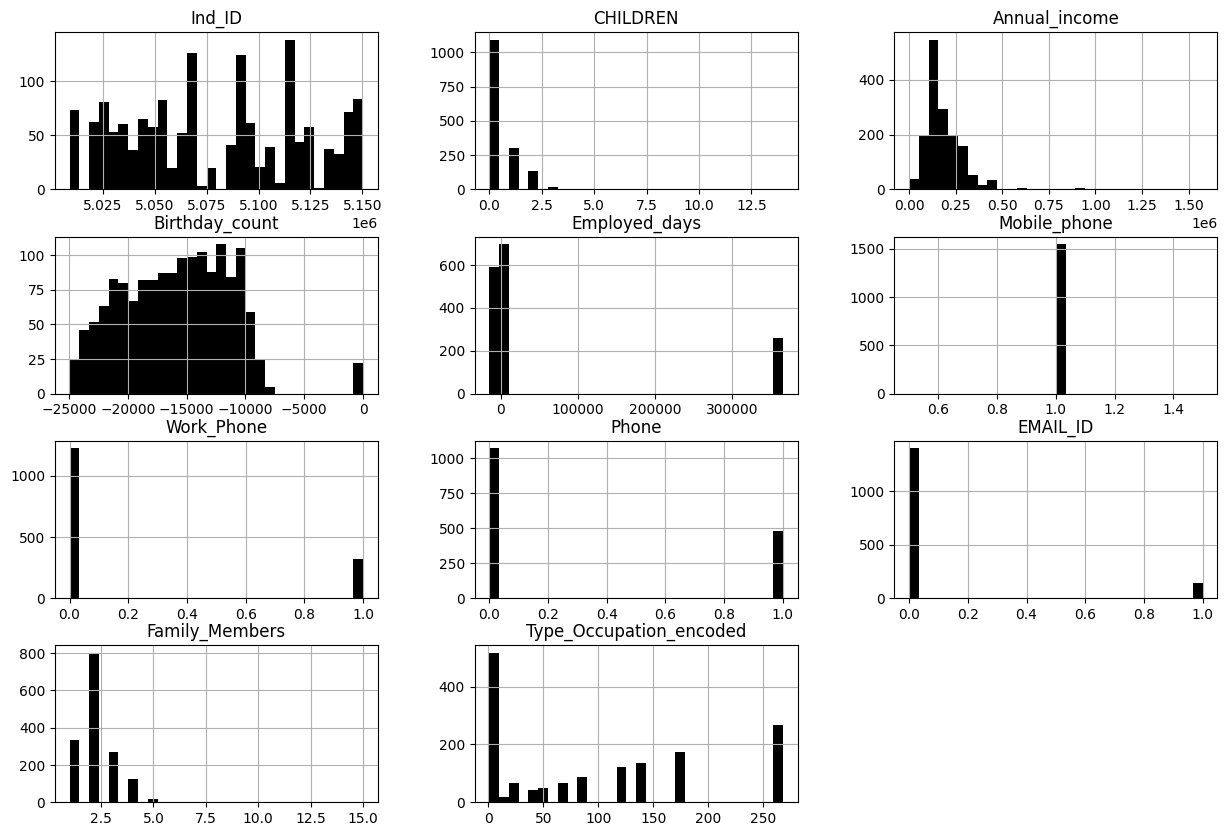

In [30]:
df.hist(color="k", bins=30, figsize=(15, 10))
plt.show()


In [31]:
from scipy import stats

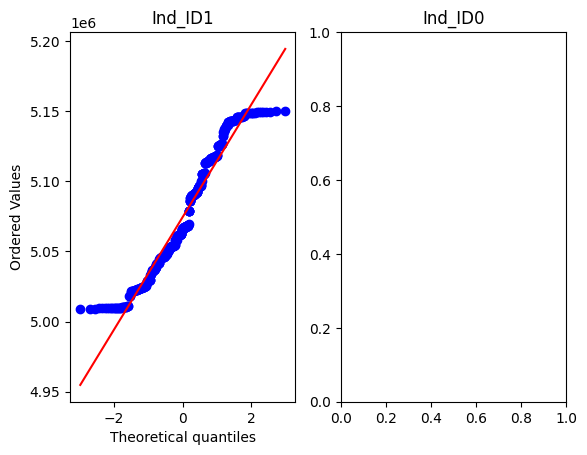

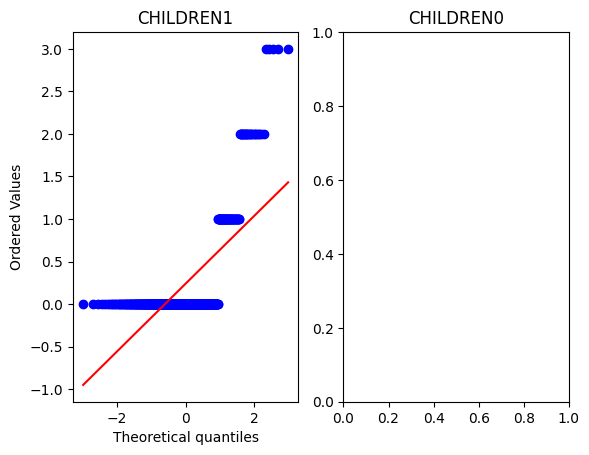

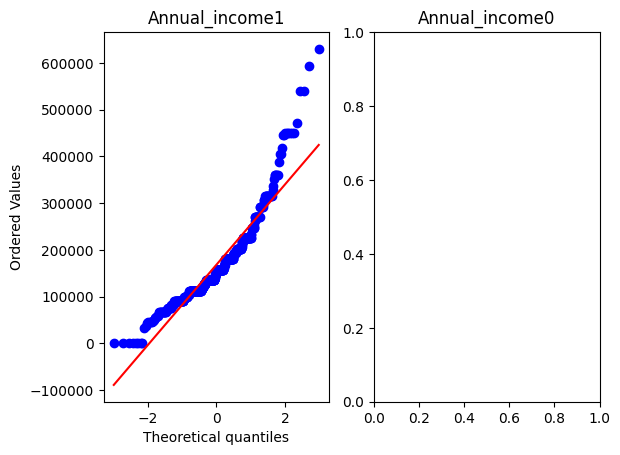

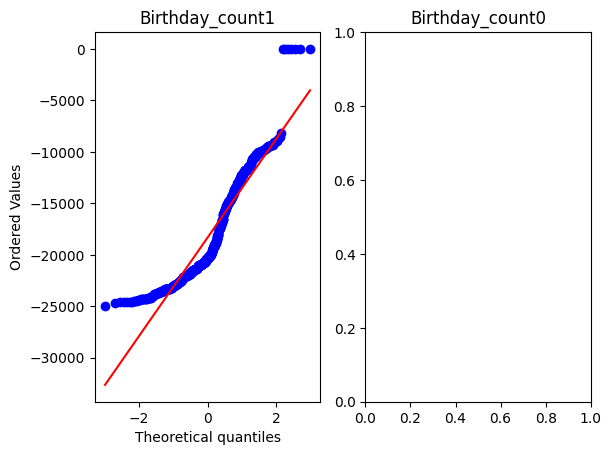

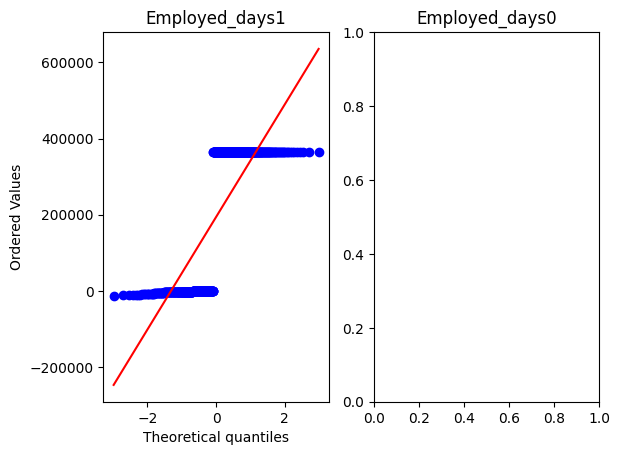

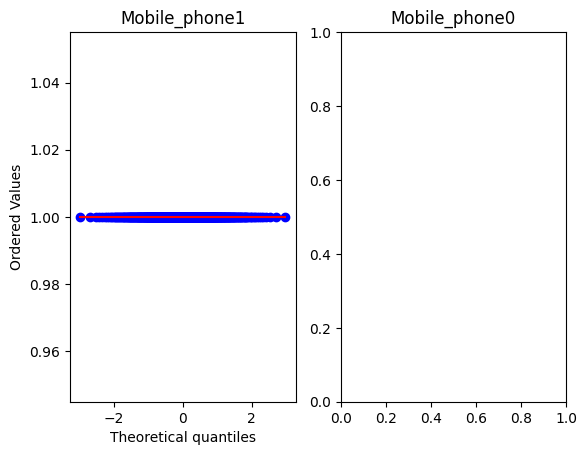

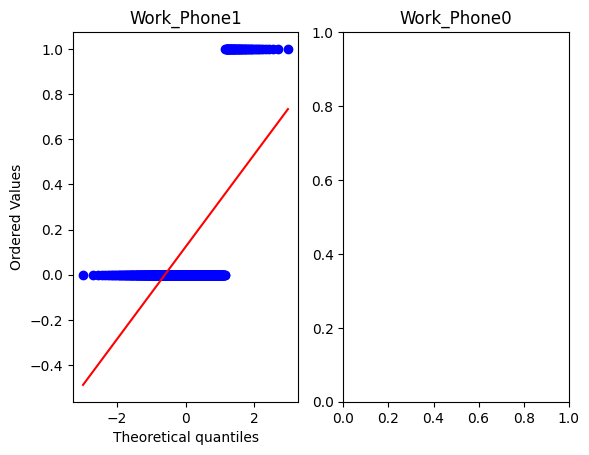

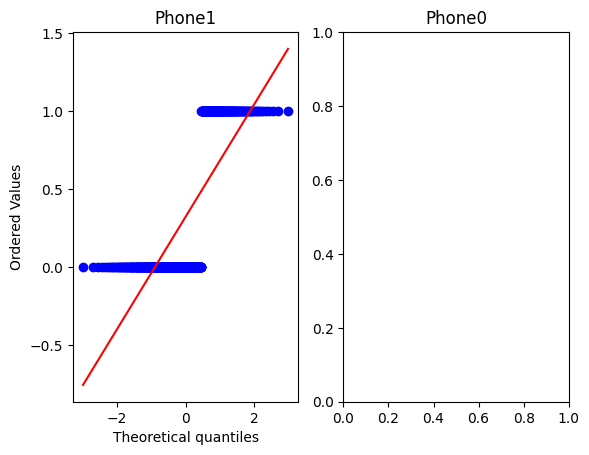

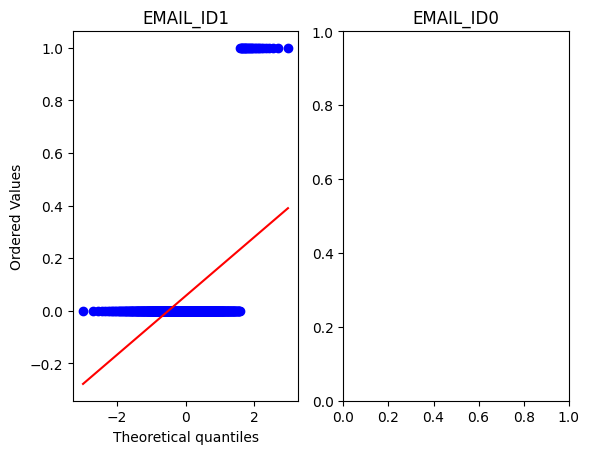

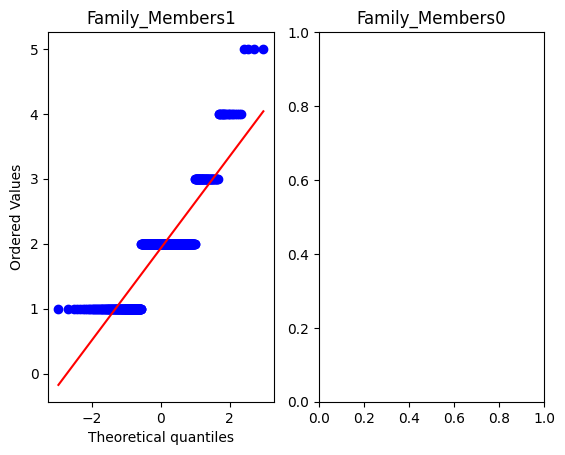

In [32]:
for name_ in num_col:
    fig1, (ax1, ax2) = plt.subplots(1,2)

    p1 = stats.probplot(df.loc[df[target] == 1,name_ ], dist=stats.norm, plot=ax1)
    p2 = stats.probplot(df.loc[df[target] == 0,name_ ], dist=stats.norm, plot=ax2)

    ax1.set_title(name_ +'1')
    ax2.set_title(name_+'0')


Вывод: Законы не нормальные

**Анализ в разрезе целевой переменной**
  - для непрерывных и дискретных признаков:
    - для классификации делим выборку по целевому признаку
    - для регрессии строим диаграммы рассеивания по целевому признаку

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


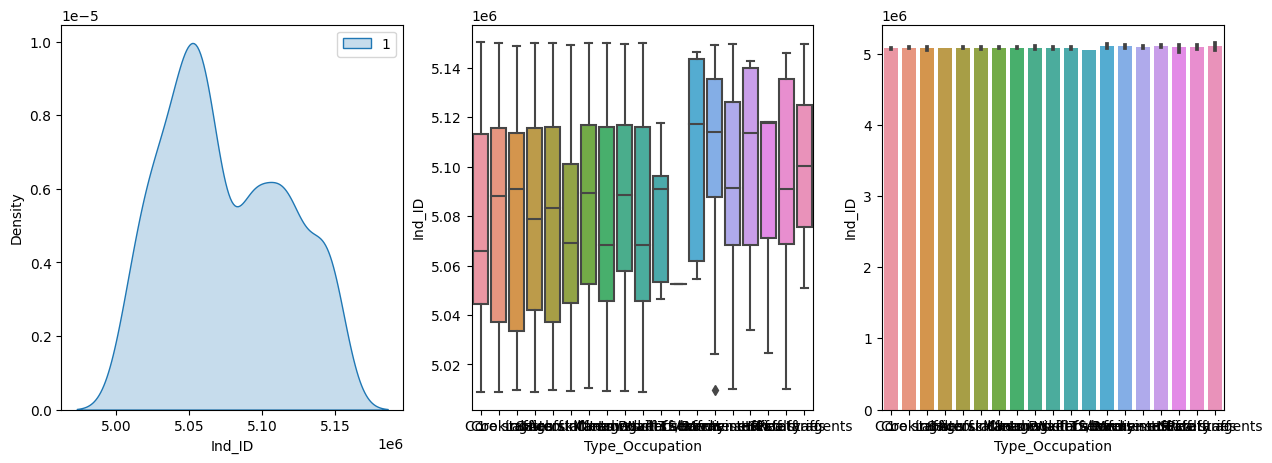

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


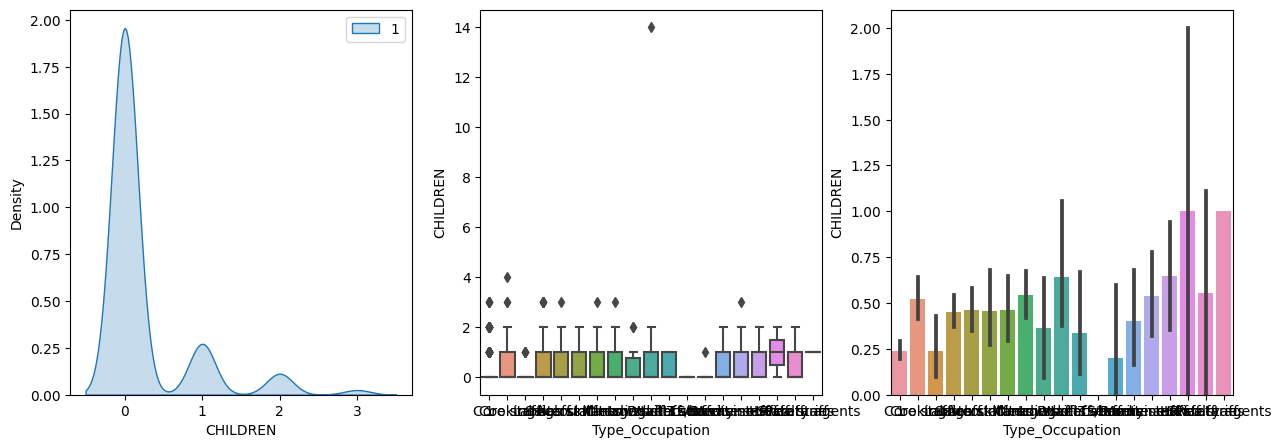

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


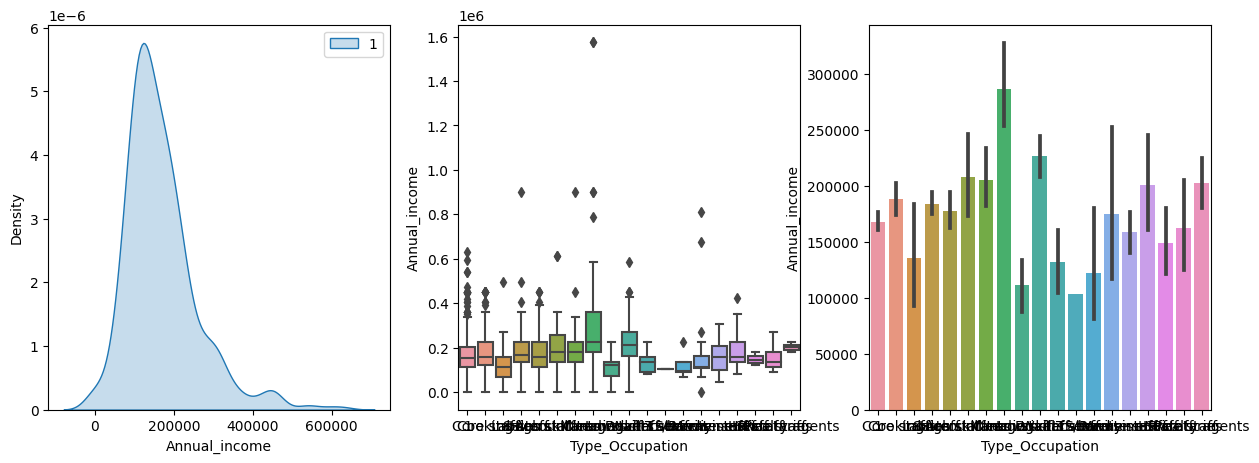

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


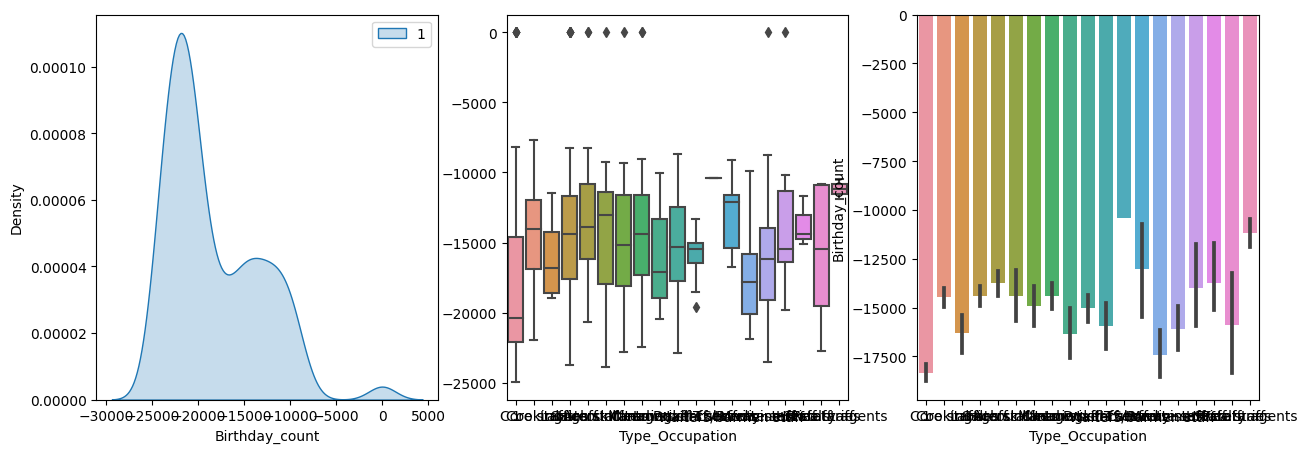

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


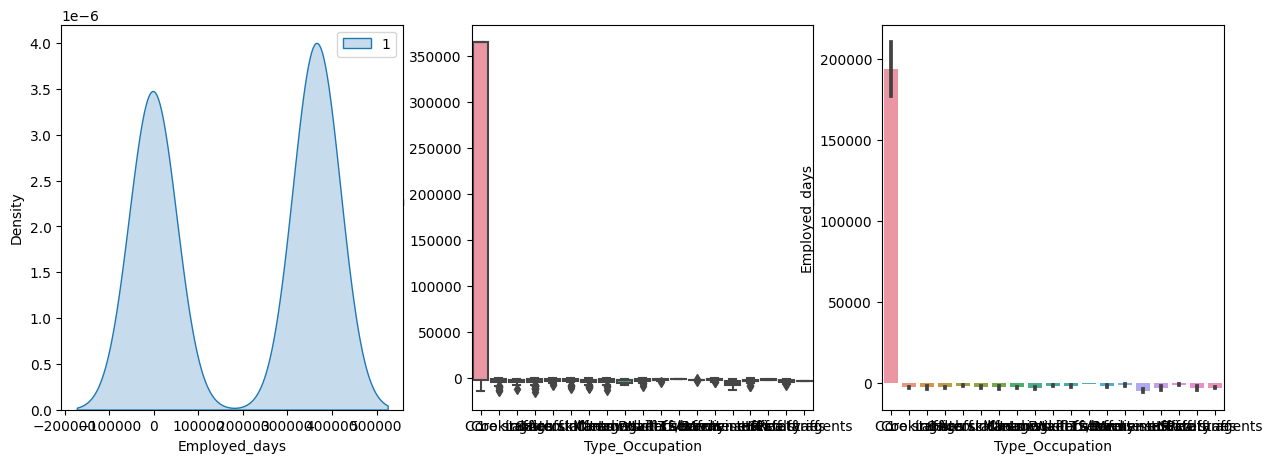

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


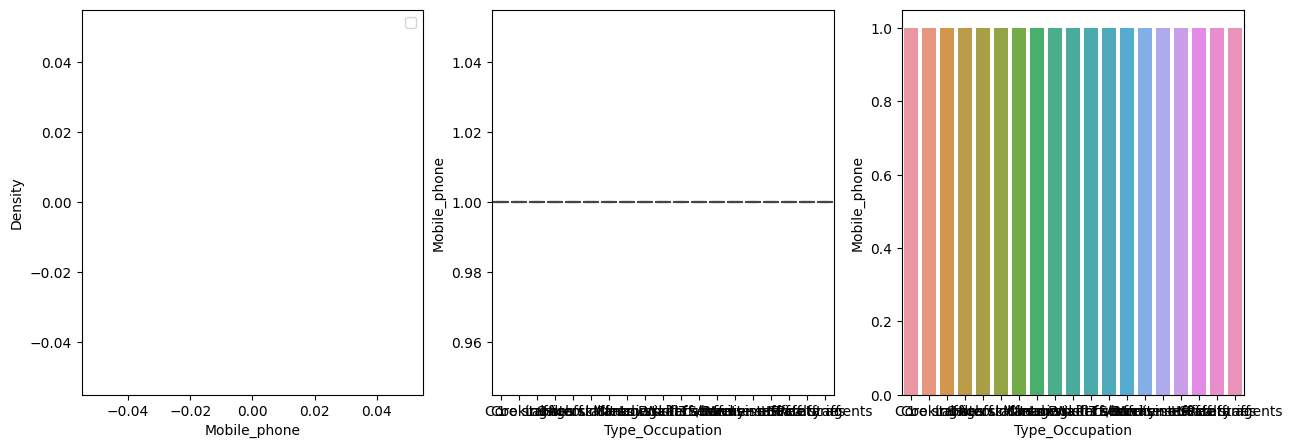

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


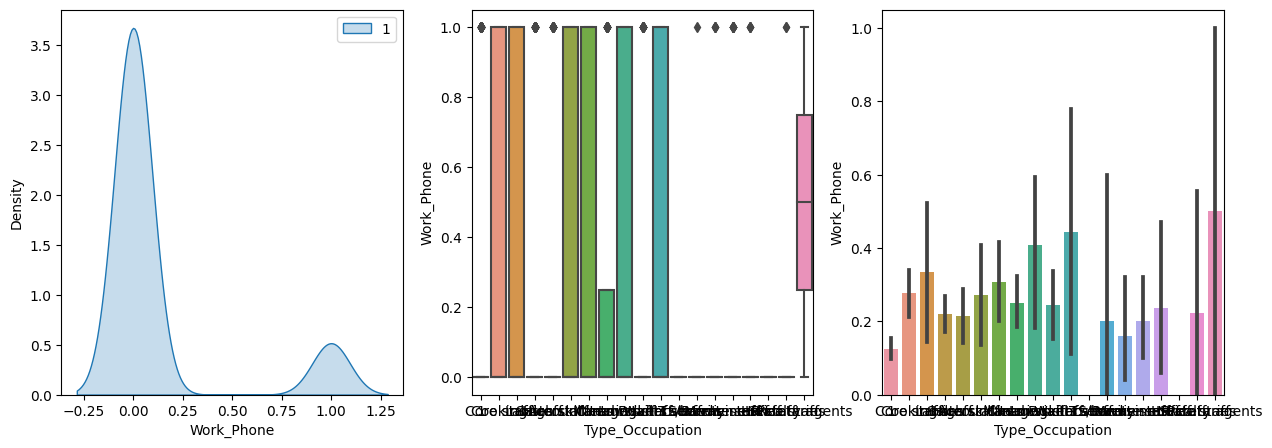

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


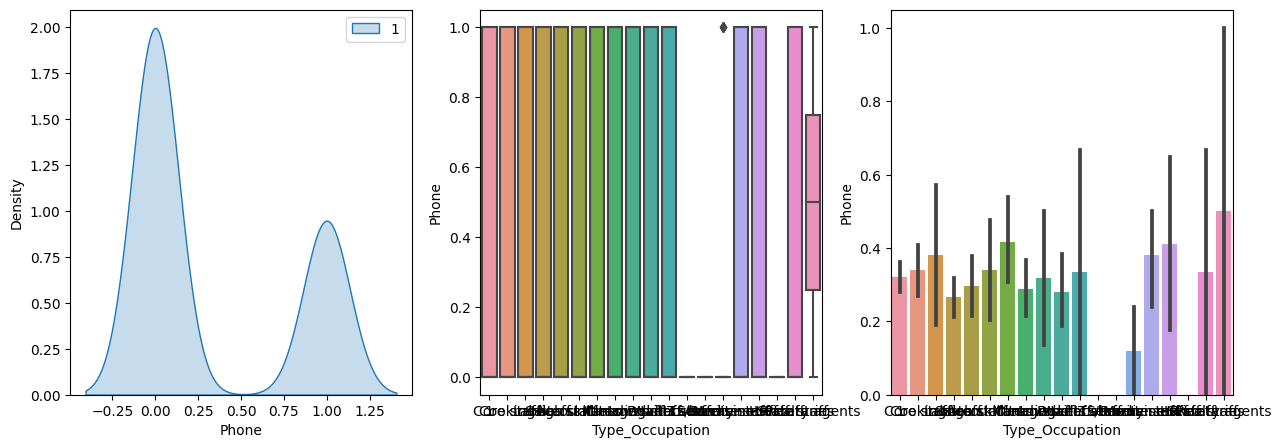

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


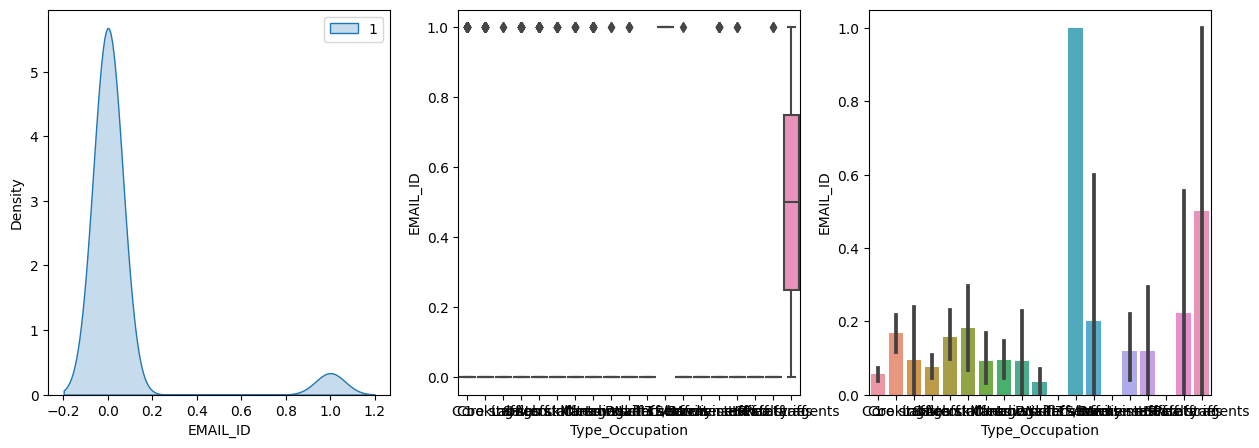

<ipython-input-33-71f21f1cb947>:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
<ipython-input-33-71f21f1cb947>:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)


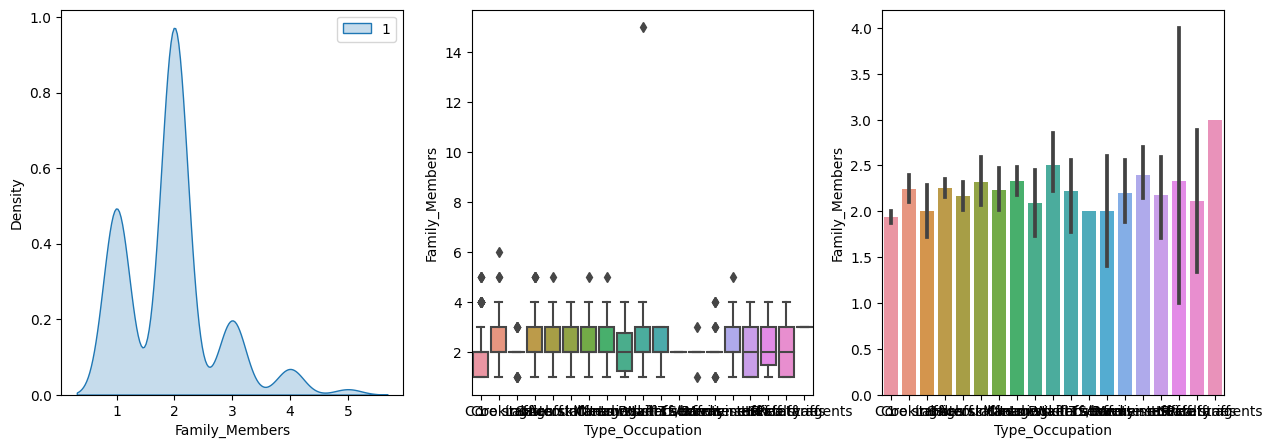

In [33]:
import seaborn as sns

for name_ in num_col:
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 2)
    sns.boxplot(x=target, y=name_, data=df)

    plt.subplot(1, 3, 3)
    sns.barplot(x=target, y=name_, data=df)

    plt.subplot(1, 3, 1)
    try:
        sns.kdeplot(df.loc[df[target] == 1, name_], label='1', shade=True)
        sns.kdeplot(df.loc[df[target] == 0, name_], label='0', shade=True)
        plt.legend()
    except:
        print('no kde')

    plt.show()


Skipping scatter plot for non-numeric column 'Ind_ID' or 'target'.


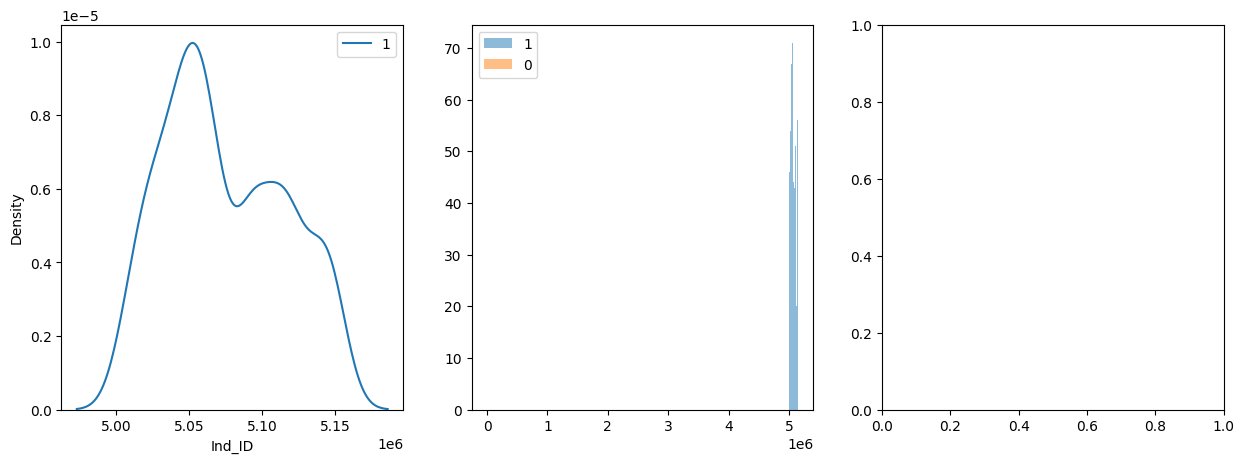

Skipping scatter plot for non-numeric column 'CHILDREN' or 'target'.


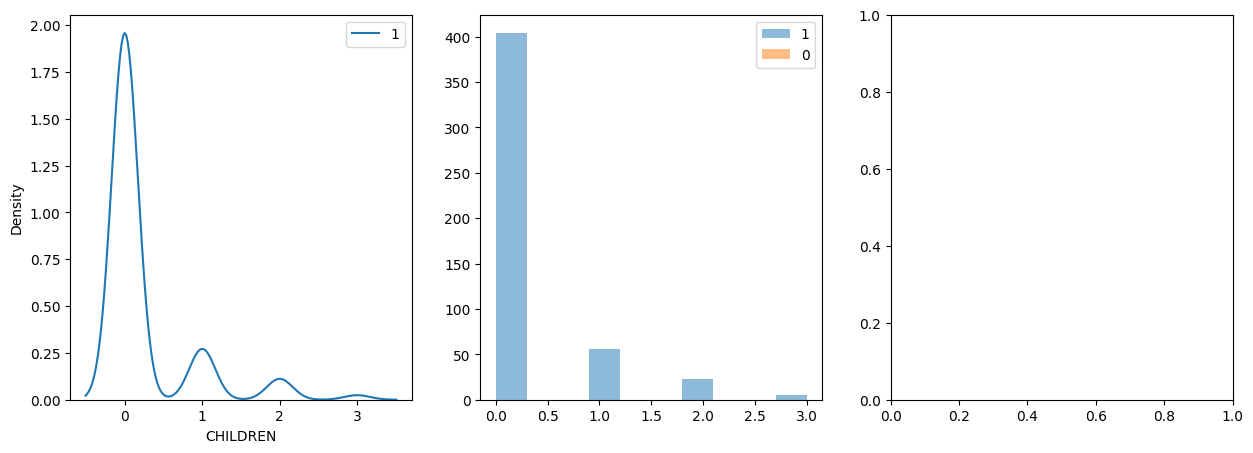

Skipping scatter plot for non-numeric column 'Annual_income' or 'target'.


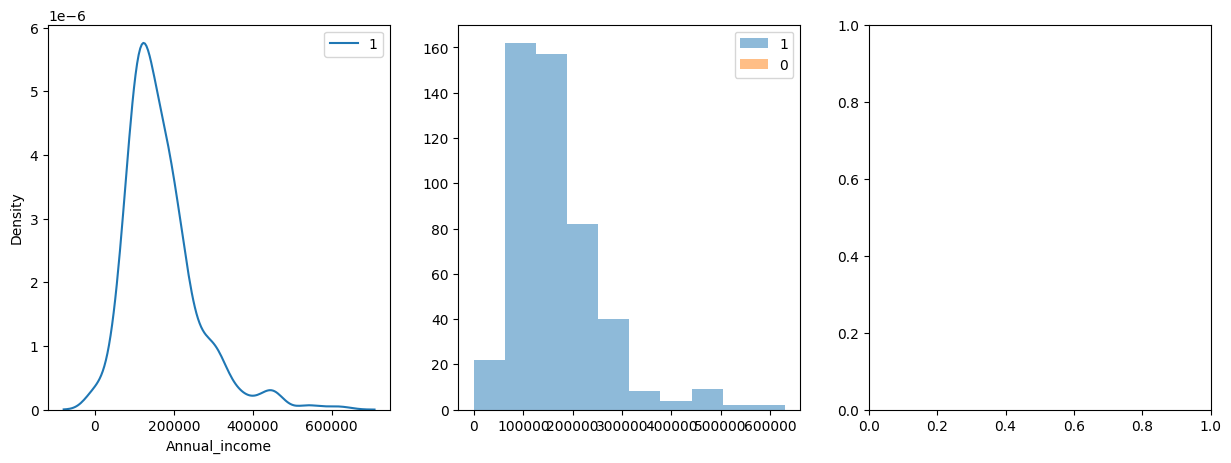

Skipping scatter plot for non-numeric column 'Birthday_count' or 'target'.


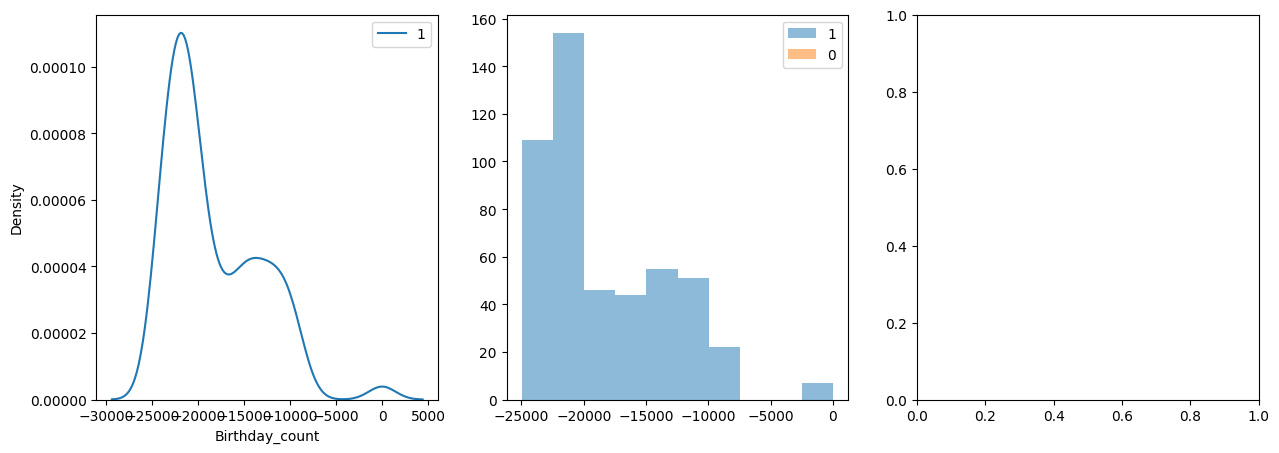

Skipping scatter plot for non-numeric column 'Employed_days' or 'target'.


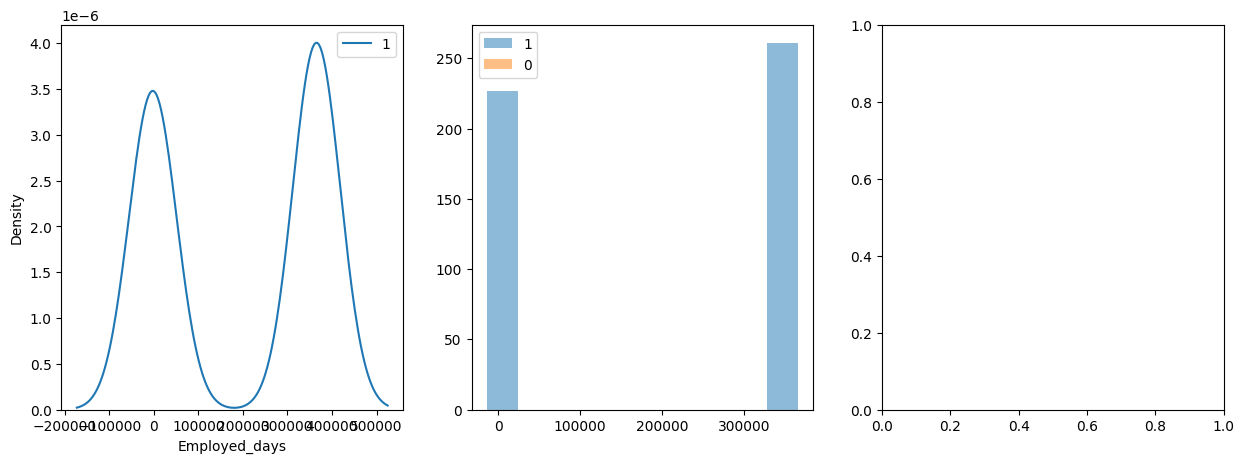

<ipython-input-34-e41fea94d9b2>:17: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[df[target] == 1, name_], label='1')


Skipping scatter plot for non-numeric column 'Mobile_phone' or 'target'.


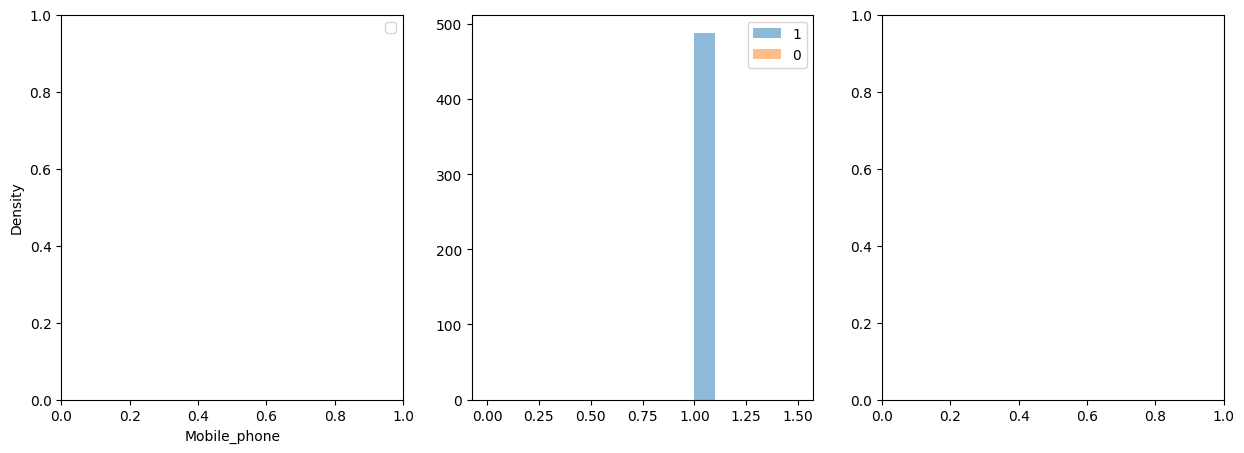

Skipping scatter plot for non-numeric column 'Work_Phone' or 'target'.


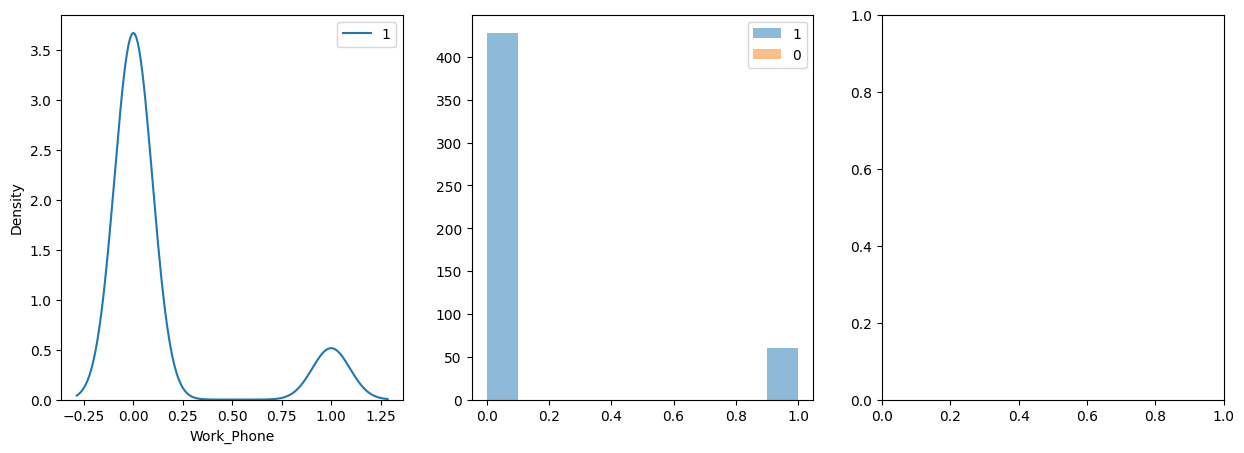

Skipping scatter plot for non-numeric column 'Phone' or 'target'.


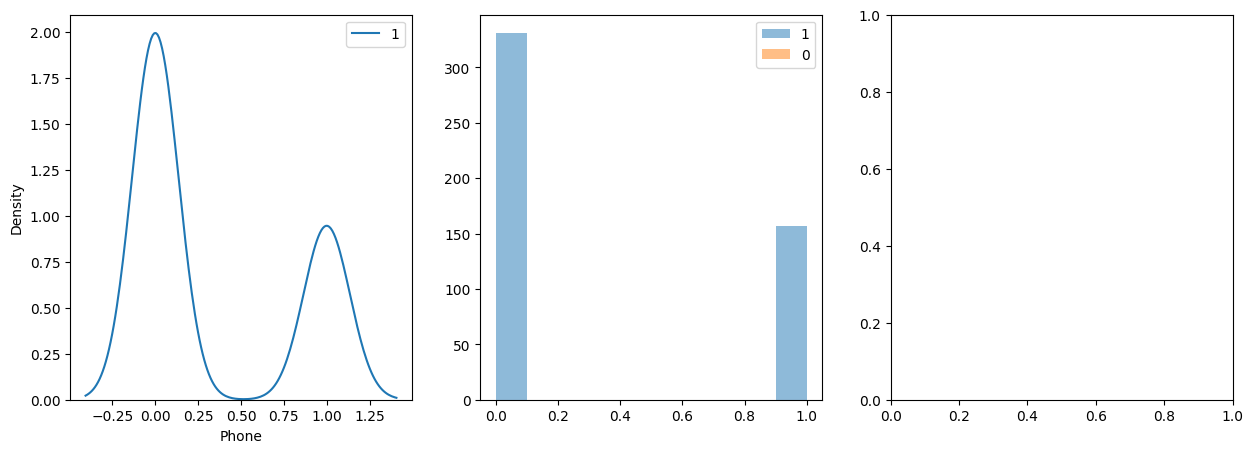

Skipping scatter plot for non-numeric column 'EMAIL_ID' or 'target'.


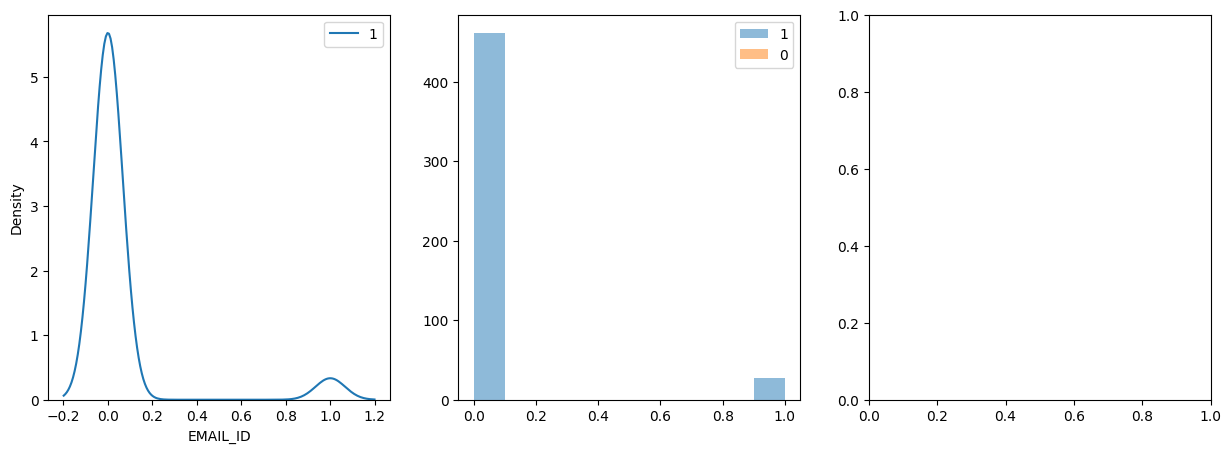

Skipping scatter plot for non-numeric column 'Family_Members' or 'target'.


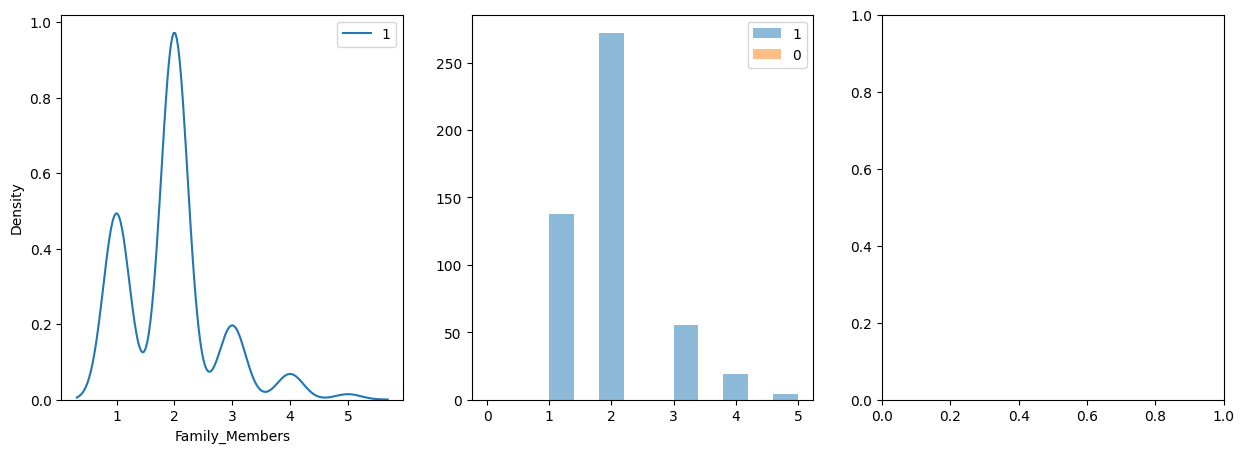

In [34]:
for name_ in num_col:
    if df[name_].dtype in [int, float]:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 2)
        plt.hist(df.loc[df[target] == 1, name_], label='1', alpha=0.5)
        plt.hist(df.loc[df[target] == 0, name_], label='0', alpha=0.5)
        plt.legend()
        plt.subplot(1, 3, 3)
        # Check if the 'name_' and 'target' columns contain numeric data
        if df[name_].dtype in [int, float] and df[target].dtype in [int, float]:
            plt.plot(df[name_], df[target], '.')
            plt.legend()
        else:
            print(f"Skipping scatter plot for non-numeric column '{name_}' or 'target'.")
        plt.subplot(1, 3, 1)
        try:
            sns.kdeplot(df.loc[df[target] == 1, name_], label='1')
            sns.kdeplot(df.loc[df[target] == 0, name_], label='0')
            plt.legend()
        except:
            print('no kde')
        plt.show()


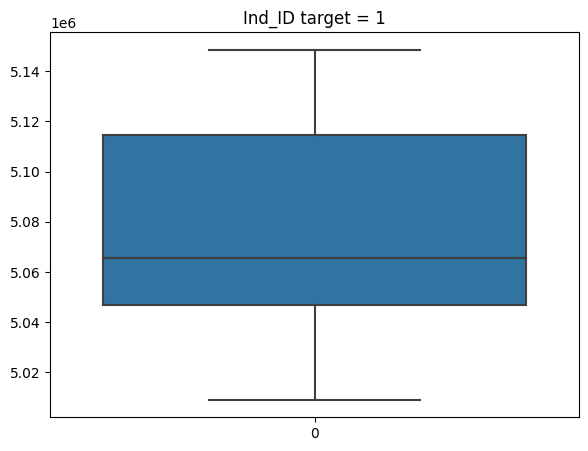

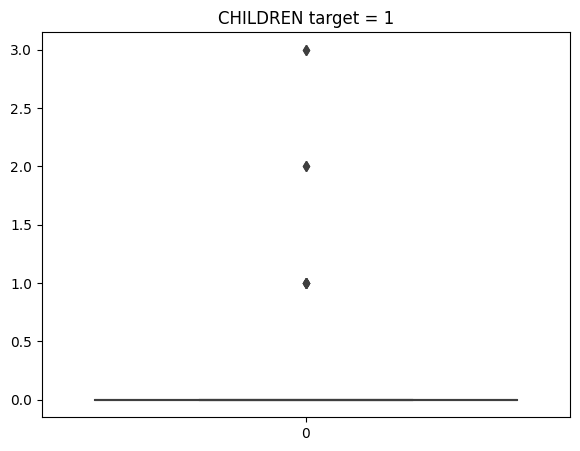

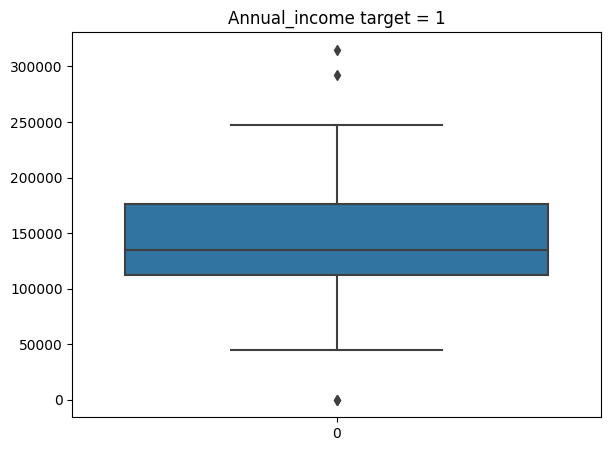

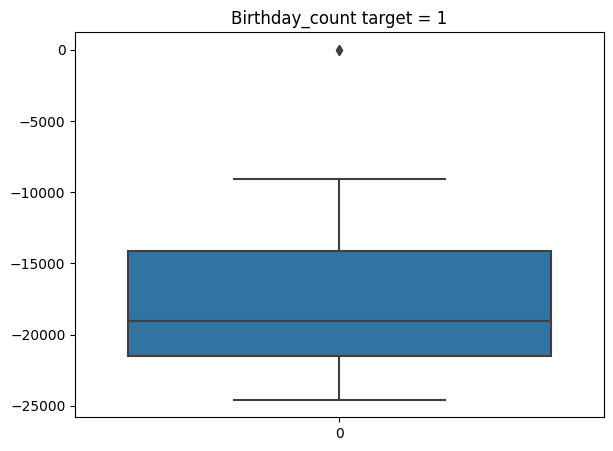

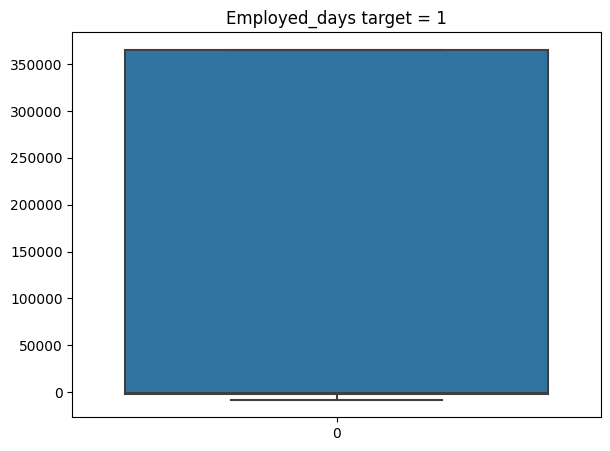

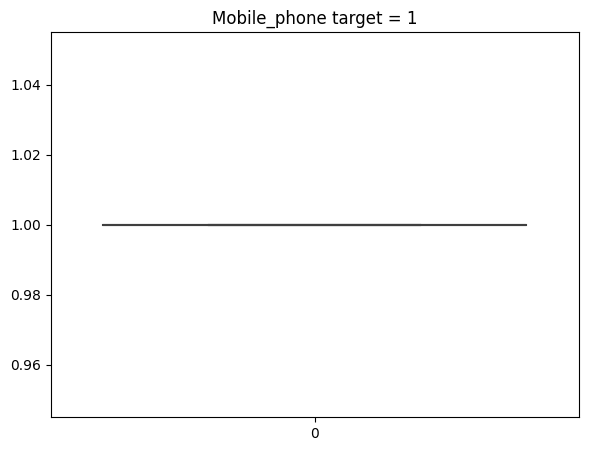

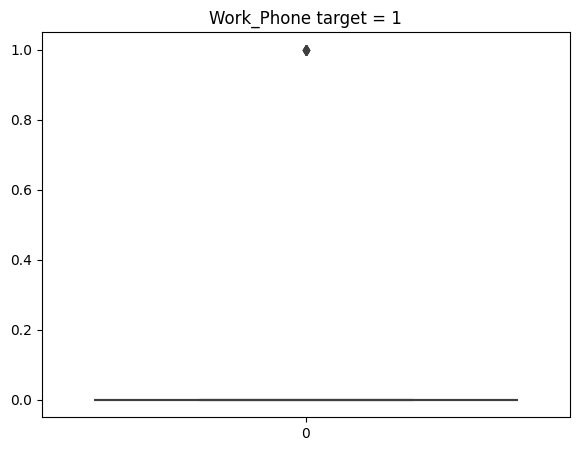

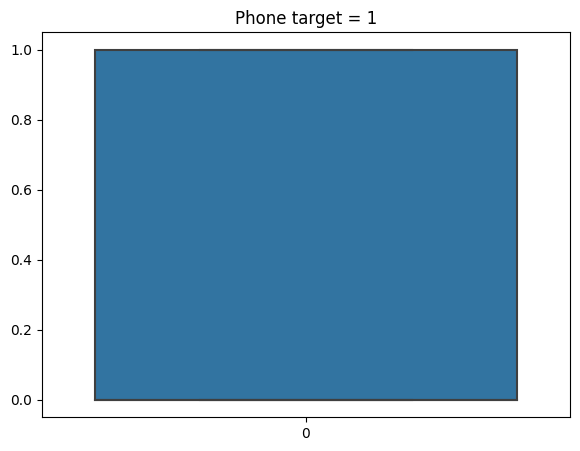

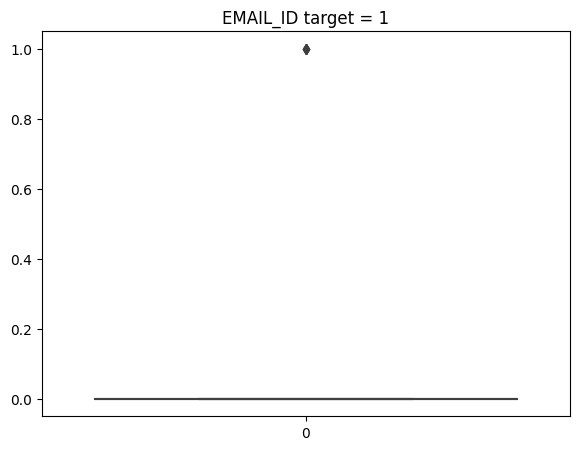

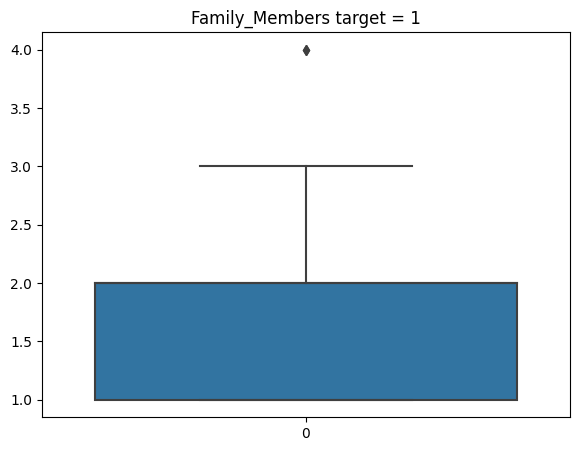

In [35]:
for name_ in num_col:
    dfs = df.sample(frac=0.1)
    plt.figure(figsize=(15, 5))

    if 1 in dfs[target].unique():
        plt.subplot(1, 2, 1)
        plt.title(name_ + ' target = 1')
        sns.boxplot(dfs.loc[dfs[target] == 1, name_].values)

    if 0 in dfs[target].unique():
        plt.subplot(1, 2, 2)
        plt.title(name_ + ' target = 0')
        sns.boxplot(dfs.loc[dfs[target] == 0, name_].values)

    plt.show()


In [36]:
for name_ in num_col:
    filtered_data = df[df[target].isin([0, 1])]
    if filtered_data.empty:
        print(f"No data available for {name_}.")
    else:
        dfs = filtered_data.sample(frac=0.1)
        # Проверка, что есть данные с target=0
        if (dfs[target] == 0).any():
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 2, 1)
            plt.title(name_ + ' target = 1')
            sns.boxplot(dfs.loc[dfs[target] == 1, name_].values)
            plt.subplot(1, 2, 2)
            if (dfs[target] == 0).any():
                sns.boxplot(dfs.loc[dfs[target] == 0, name_].values)
                plt.title(name_ + ' target = 0')
                plt.show()
        else:
            print(f"No data with {name_} for target = 0.")


No data with Ind_ID for target = 0.
No data with CHILDREN for target = 0.
No data with Annual_income for target = 0.
No data with Birthday_count for target = 0.
No data with Employed_days for target = 0.
No data with Mobile_phone for target = 0.
No data with Work_Phone for target = 0.
No data with Phone for target = 0.
No data with EMAIL_ID for target = 0.
No data with Family_Members for target = 0.


Если для каждой из перечисленных характеристик (Ind_ID, CHILDREN, Annual_income, и т. д.) отсутствуют данные с 'target = 0', это означает, что для этих характеристик все имеющиеся данные в вашем наборе данных соответствуют 'target = 1'.

В этом случае, "boxplot" для 'target = 0' не создаётся, потому что нет данных с этим значением 'target'. Это вполне нормальная ситуация, и это означает, что эти характеристики (Ind_ID, CHILDREN, Annual_income и другие) не разделяются по 'target' в  наборе данных, и их можно рассматривать как характеристики, для которых 'target' всегда равен 1.

**Вывод:**
    - Выбросы есть
    - закон распределенгия не нормальный (Гипотеза : провести нормализацию через логарифмические преобразования)

Для категорийных признаков смотрим на частоты вдоль целевого свойства

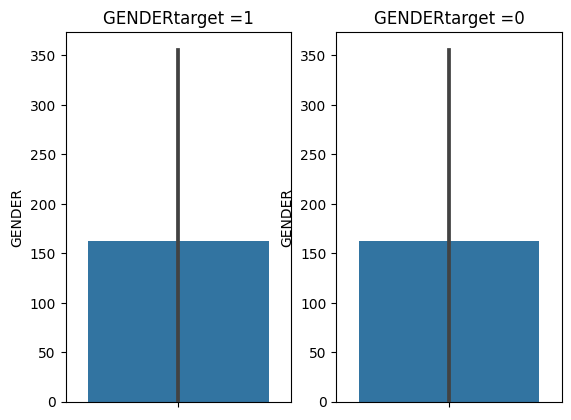

GENDER: 
 [[356, 130, 2], [356, 130, 2]]


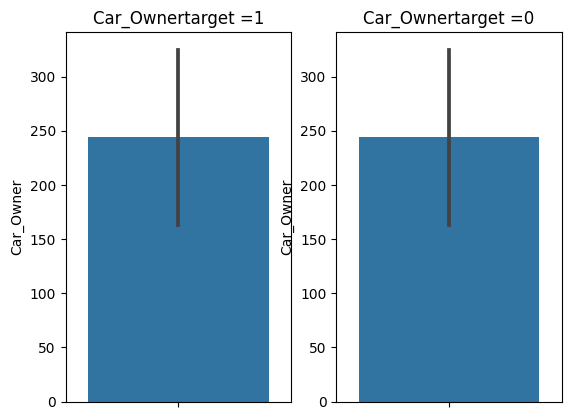

Car_Owner: 
 [[325, 163], [325, 163]]


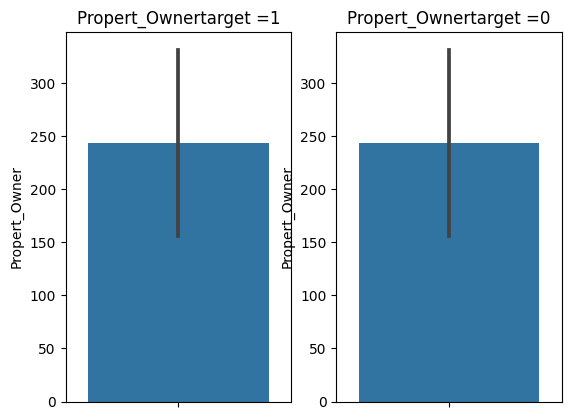

Propert_Owner: 
 [[332, 156], [332, 156]]


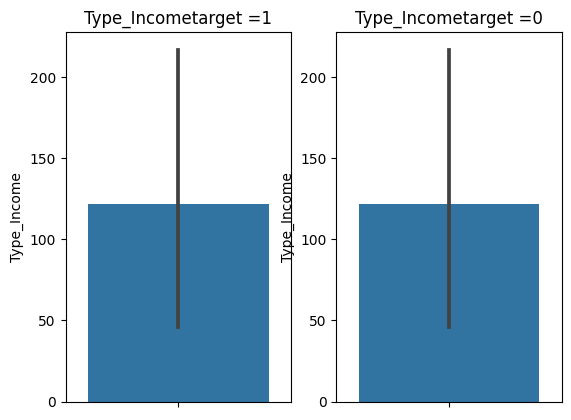

Type_Income: 
 [[264, 129, 77, 18], [264, 129, 77, 18]]


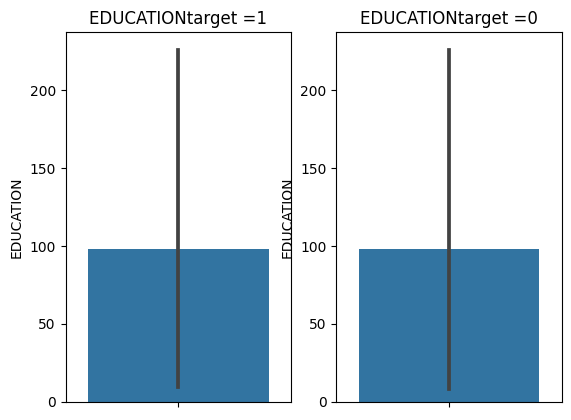

EDUCATION: 
 [[334, 118, 25, 9, 2], [334, 118, 25, 9, 2]]


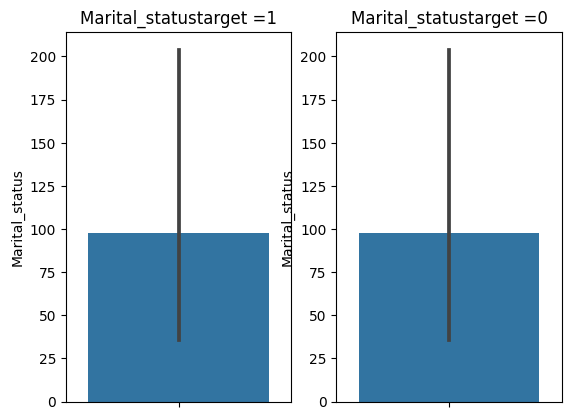

Marital_status: 
 [[310, 64, 51, 37, 26], [310, 64, 51, 37, 26]]


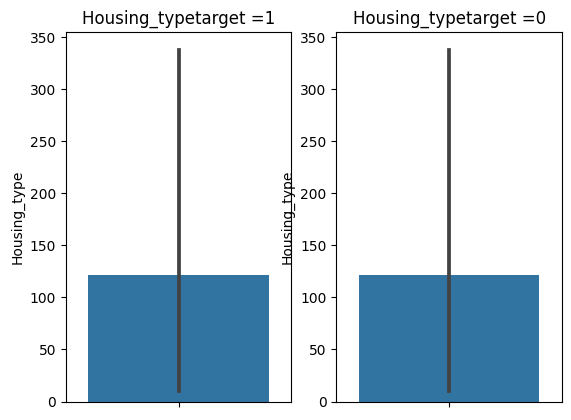

Housing_type: 
 [[447, 21, 12, 8], [447, 21, 12, 8]]


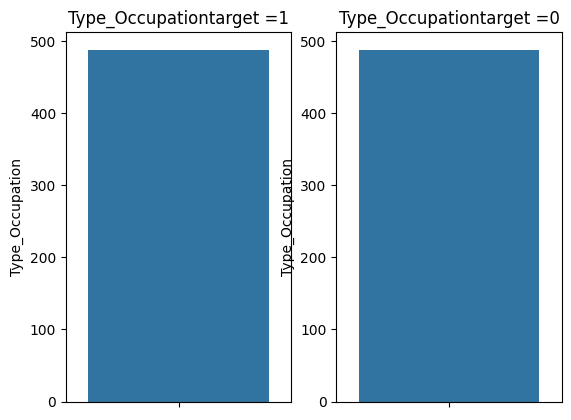

Type_Occupation: 
 [[488], [488]]


In [37]:
cat_hist ={}
for name_ in n_col:
    dfs = df.sample(frac=1)
    d1 = dfs.loc[dfs[target]==1,name_ ].value_counts()
    d0 = dfs.loc[dfs[target]==1,name_ ].value_counts()
    dn = [d1.values.T.tolist(),d0.values.T.tolist()]
    plt.subplot(1,2,1)
    plt.title(name_+'target =1')
    sns.barplot(d1,y=d1.index)
    plt.subplot(1,2,2)
    plt.title(name_+'target =0')
    sns.barplot(d0,y=d0.index)
    plt.show()
    cat_hist[name_]=dn
    print(name_+': \n',dn)

**Вывод:** посмотреть на различия признаков по классам или интервалам значений целевого свойства

### 7. Селекция

Фильтрация:
   - для непрерывных признаков - корреляции

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Text(0.5, 1.0, 'Взаимные парные корреляции признаков')

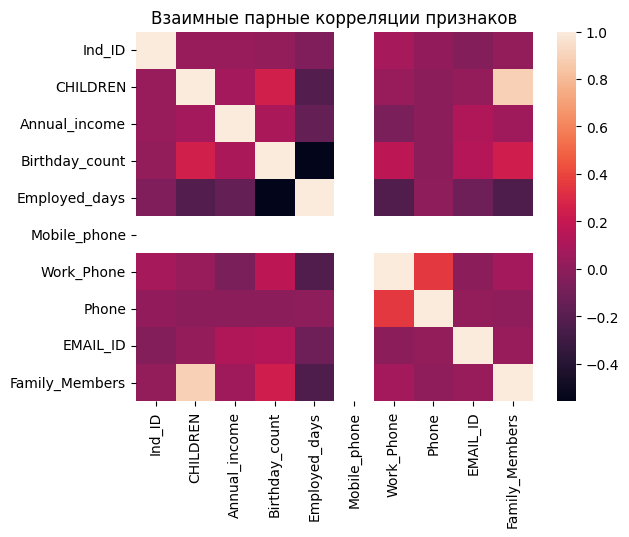

In [38]:
# Взаимные парные корреляции признаков
cc=np.corrcoef(df.loc[:,num_col].values.T)

sns.heatmap(data=cc, xticklabels=df.loc[:,num_col].columns, yticklabels=df.loc[:,num_col].columns)
plt.title('Взаимные парные корреляции признаков')

Для вывода: ищем сс больше 0.7 - это мультиколлинеарность

In [39]:
np.where(cc>0.6)

(array([0, 1, 1, 2, 3, 4, 6, 7, 8, 9, 9]),
 array([0, 1, 9, 2, 3, 4, 6, 7, 8, 1, 9]))

Все значения на диагонали, это сам с собой.

**Вывод**: мультиколлинеарных нет

- для категорийных - анализ частот:
Можно сделать стат.тесты для категорийных и численных признаков:
    - различимость распределений в разрезе целевой переменной (определит важность признака - чем различимей, тем лучше) -  ttest_rel
    - сходство частот (позволит уменьшить число категорий в признаке для номинальных) chi2_contingency

In [40]:
from scipy.stats import shapiro, normaltest, ttest_rel, ttest_ind, kstest
from scipy.stats import ks_2samp, chi2_contingency

In [41]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,Type_Occupation_encoded
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,1,2,1.0
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1.0,-586,1,1,1,0,1,2,1.0
3,5009749,F,Y,N,0,1.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,1,2,1.0


In [42]:
df['Ind_ID'] = np.arange(df.shape[0])

In [43]:
def cat_merge(X_, Y10, Ind_ID, FEATURE_NAME):
    TARGET_NAME = 'Y10'
    X_[TARGET_NAME] = Y10
    b_max = len(X_[FEATURE_NAME].unique())  # сколько категорий
    CHI_ = []
    numb_b = {}
    # смотрим на пары категорий
    for i_br in X_[FEATURE_NAME].unique():
        # сохраняем число примеров для этого значения по всем данным
        numb_b[str(i_br)] = X_.loc[X_[FEATURE_NAME].isin([i_br]), :].shape[0]
        for j_br in X_[FEATURE_NAME].unique():
            # выделили подтаблицу
            X_d = X_.loc[X_[FEATURE_NAME].isin([i_br, j_br]), [Ind_ID, FEATURE_NAME, TARGET_NAME]]
            # выбираем число примеров для оценки в тесте Хи2
            if X_d.shape[0] > 1000:
                n_samples = 1000
            else:
                n_samples = X_d.shape[0]
            # если значения есть, то оценим, иначе p=0
            if n_samples > 0:
                rez_s = X_.loc[X_[FEATURE_NAME].isin([i_br, j_br]), [Ind_ID, FEATURE_NAME, TARGET_NAME]].sample(n_samples)
                # частоты по значениям цели для значений признака
                table = rez_s.pivot_table(values=Ind_ID, index=TARGET_NAME, columns=FEATURE_NAME, aggfunc='count') + 5
                table.fillna(5, inplace=True)
                chi2, p, dof, expected = chi2_contingency(table, correction=False)
            else:
                p = 0
            CHI_.append(p)
    CHI_ = np.array(CHI_).reshape((b_max, b_max))
    # чем белее, тем больше оснований для объединения значений
    sns.heatmap(data=CHI_, xticklabels=X_[FEATURE_NAME].unique(), yticklabels=X_[FEATURE_NAME].unique())
    print(numb_b)
    return CHI_, numb_b



In [44]:
chi_bed, numb_bed = cat_merge(df.loc[:, n_col[:1]], df[target], 'Ind_ID', n_col[0])

KeyError: ignored

Вывод: нет когеррентных

Сделаем категорийные признаки числовыми (pd.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False, dtype=None)):
    

In [45]:
n_col

Index(['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION',
       'Marital_status', 'Housing_type', 'Type_Occupation'],
      dtype='object')

In [46]:
df = pd.get_dummies(df,columns = n_col, prefix=n_col, prefix_sep='_', dummy_na=True )

df.head()

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members,...,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Waiters/barmen staff,Type_Occupation_nan
0,0,0,180000.0,-18772.0,365243,1,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
1,1,0,315000.0,-13557.0,-586,1,1,1,0,2,...,0,0,0,0,0,0,0,0,0,0
2,2,0,315000.0,1.0,-586,1,1,1,0,2,...,0,0,0,0,0,0,0,0,0,0
3,3,0,1.0,-13557.0,-586,1,1,1,0,2,...,0,0,0,0,0,0,0,0,0,0
4,4,0,315000.0,-13557.0,-586,1,1,1,0,2,...,0,0,0,0,0,0,0,0,0,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 65 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Ind_ID                                   1548 non-null   int64  
 1   CHILDREN                                 1548 non-null   int64  
 2   Annual_income                            1548 non-null   float64
 3   Birthday_count                           1548 non-null   float64
 4   Employed_days                            1548 non-null   int64  
 5   Mobile_phone                             1548 non-null   int64  
 6   Work_Phone                               1548 non-null   int64  
 7   Phone                                    1548 non-null   int64  
 8   EMAIL_ID                                 1548 non-null   int64  
 9   Family_Members                           1548 non-null   int64  
 10  Type_Occupation_encoded                  1548 no

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Text(0.5, 1.0, 'Взаимные парные корреляции признаков')

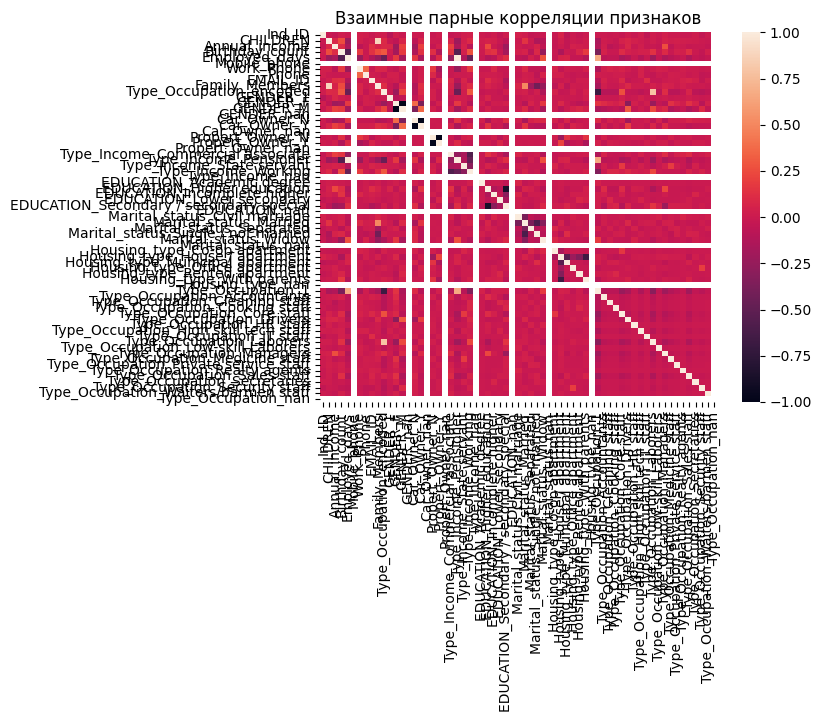

In [48]:
# Взаимные парные корреляции всех признаков
cc=np.corrcoef(df.values.T)

sns.heatmap(data=cc, xticklabels=df.columns, yticklabels=df.columns)
plt.title('Взаимные парные корреляции признаков')

In [49]:
p_c = np.where(cc>0.7)
for i in range(df.shape[1]):
    for j in range(i+1,df.shape[1]):
        if cc[i,j]>0.7:
            print('высокая корреляция ',i,' c ', j)

высокая корреляция  1  c  9
высокая корреляция  4  c  22
высокая корреляция  10  c  54


Вывод: Все признаки кроме пары 1-9, 4-22, 10-54 рабочие

### Сохранение обучающего датасета<a class="anchor" id="saving"></a>

In [50]:
df.to_csv(PREP_DATASET_PATH, index=False, encoding='utf-8')

Выводы:




## Строим линейную модель

  - создать объект
  - разделить данные на тесты и обучение
  - выбрать метрику
  - обучить объект на обучающих данных
  - оценить результат на тесте

### Собираем модели:

Типы классификаторов:
Первичный выбор делаем на моделях разных классов:
     - К ближайший сосед from sklearn.neighbors import KNeighborsClassifier
     - Логистическая регрессияfrom sklearn.linear_model import LogisticRegression
     - SVM (from sklearn.svm import SVC)
     
     
Ссылки :
- логистическая регрессия http://www.machinelearning.ru/wiki/index.php?title=%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F
- метрические модели (KNN) http://www.machinelearning.ru/wiki/images/c/c3/Voron-ML-Metric-slides.pdf
- SVM http://www.machinelearning.ru/wiki/images/a/a0/Voron-ML-Lin-SVM.pdf

In [51]:
from sklearn.linear_model import LogisticRegression, LinearRegression

In [52]:
from sklearn.svm import SVC, SVR

In [53]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [54]:
KNN = KNeighborsClassifier()
LM = LogisticRegression()
SV = SVC(gamma='auto',probability=True)
cls_= ['KNN','LM','SV']

list_class = {"cls":[KNN,LM,SV],'metric':[0,0,0]}

In [55]:
from sklearn.model_selection import train_test_split

# 1 - формируем данные
features = df.columns[:-1]


target = df.columns[-1]#'целевое свойство'


#разделим данные на train/test
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], random_state=0)
#создаем препроцессоры данных
trans_data = preprocess_data()
sc = StandardScaler()

# обучаем части препроцессора данных
X_train_trans  = trans_data.fit_transform(X_train)
sc.fit(X_train_trans)

# применяем препроцессоры данных
X_train_trans = sc.transform(X_train_trans)
X_test_trans = sc.transform(trans_data.transform(X_test))

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
df.columns[12]

'GENDER_F'

In [58]:
# 1 - формируем данные
features = list(df.columns[:12]) +  list(df.columns[13:])


target = df.columns[12]#'целевое свойство'


#разделим данные на train/test
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], random_state=0)
#создаем препроцессоры данных

sc = StandardScaler()

# обучаем части препроцессора данных

sc.fit(X_train)

# применяем препроцессоры данных
X_train_trans = sc.transform(X_train)
X_test_trans = sc.transform(X_test)

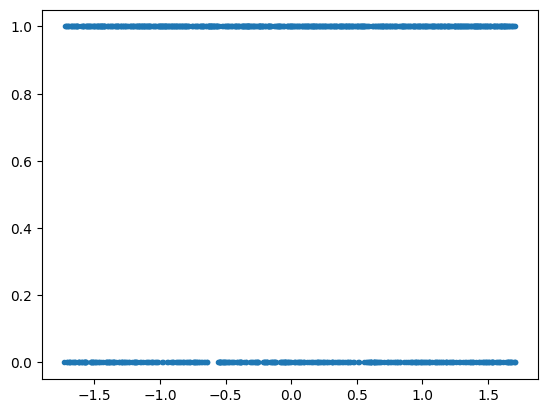

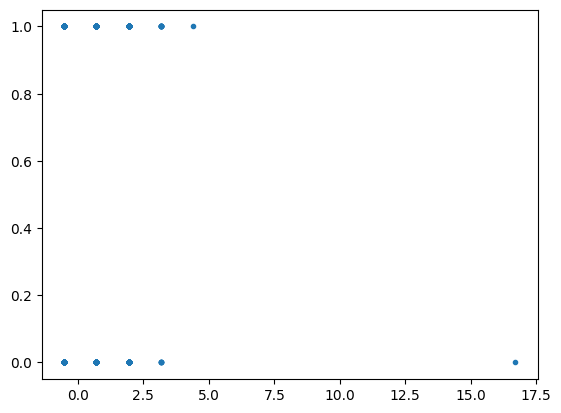

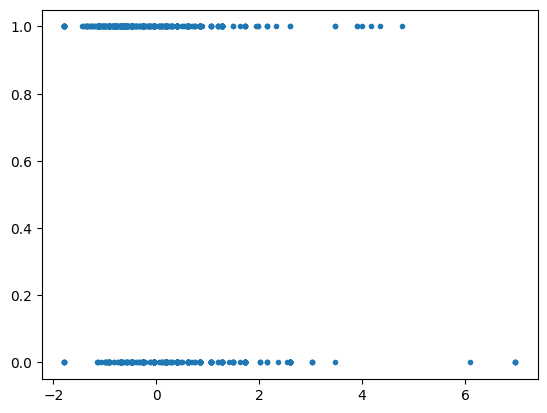

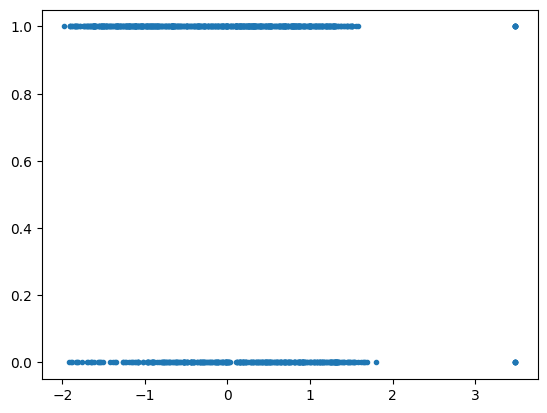

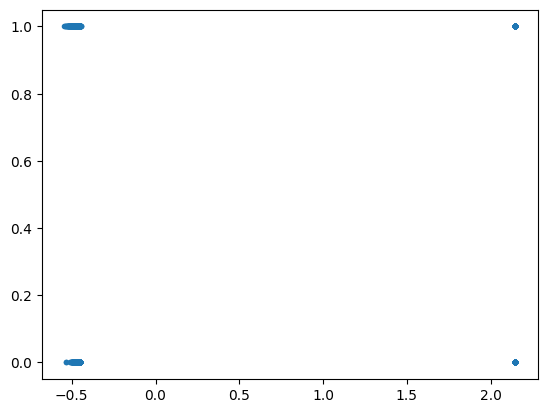

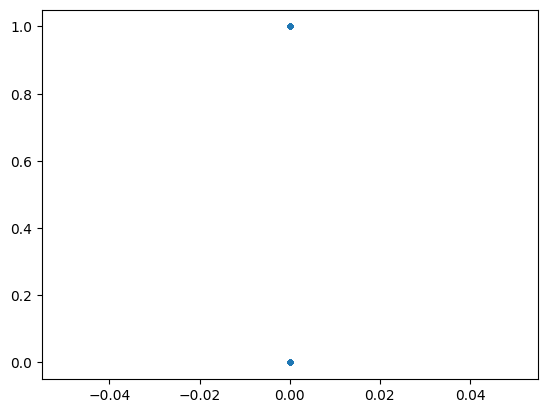

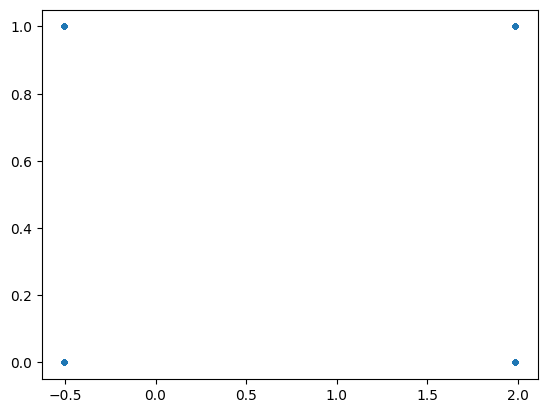

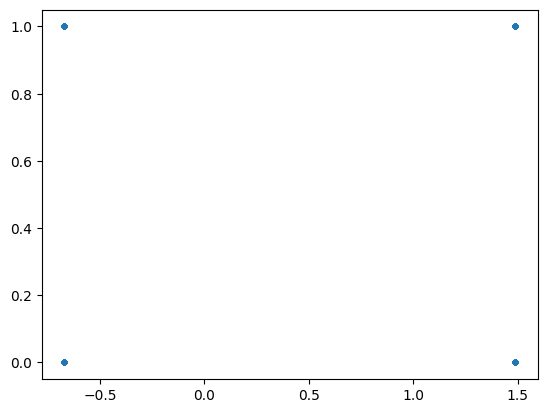

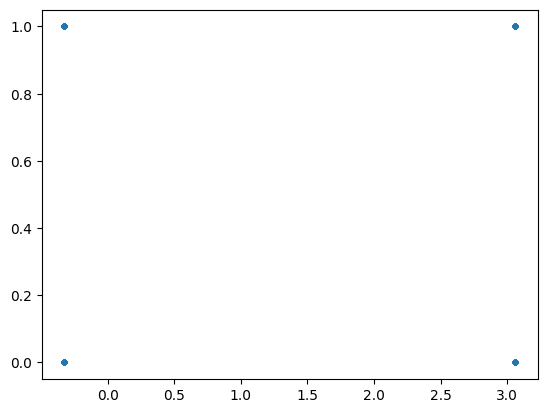

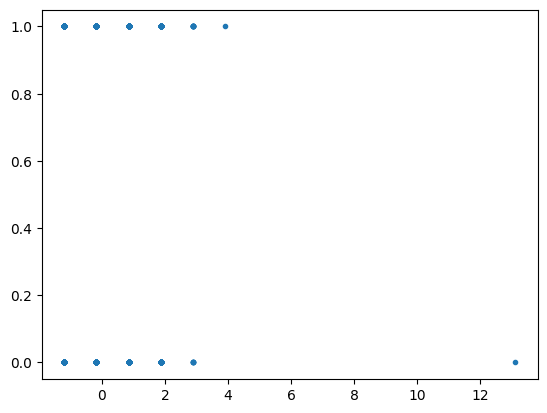

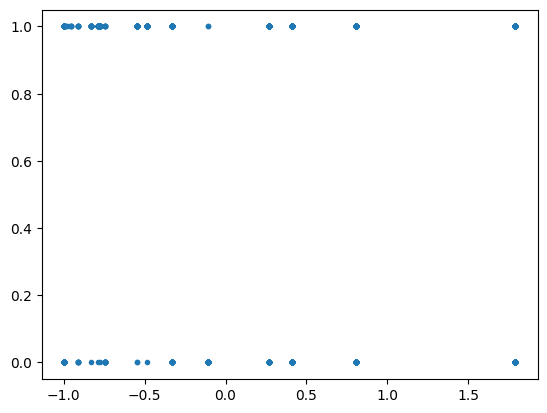

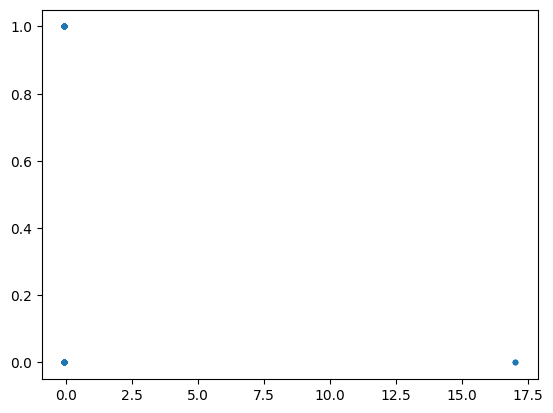

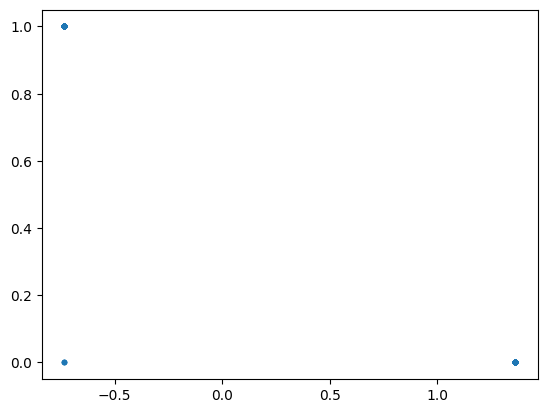

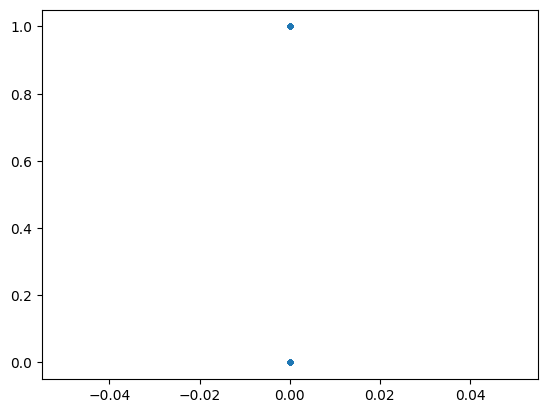

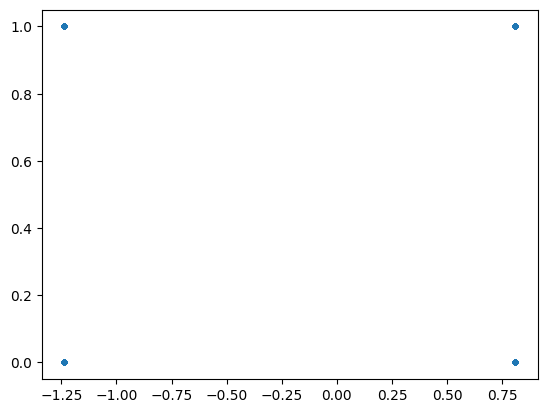

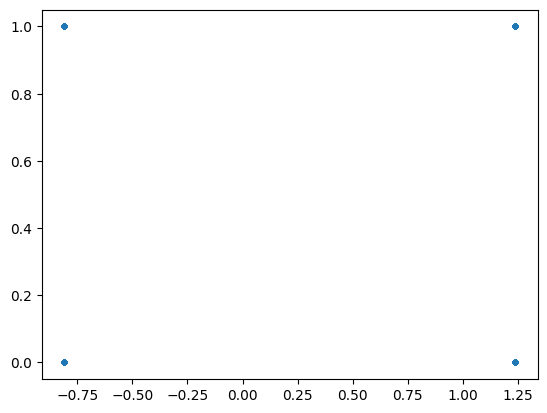

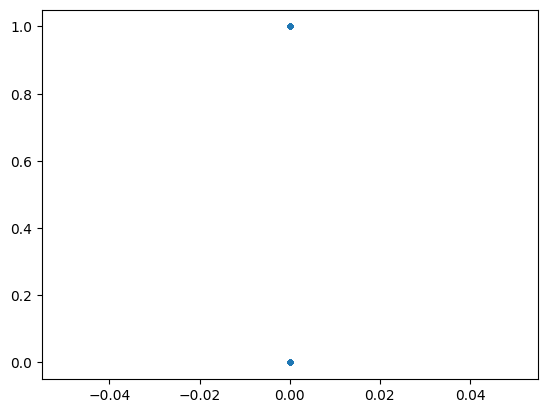

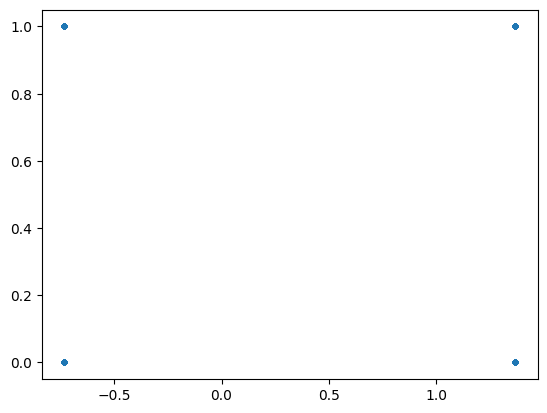

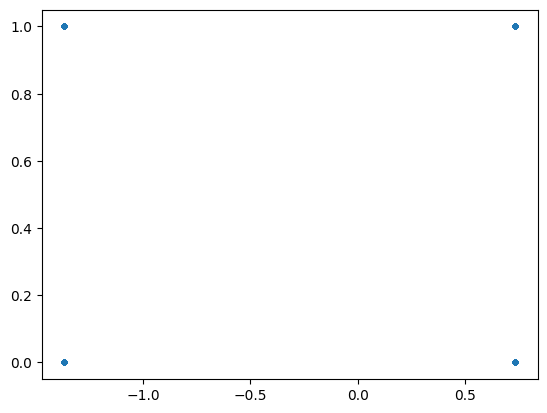

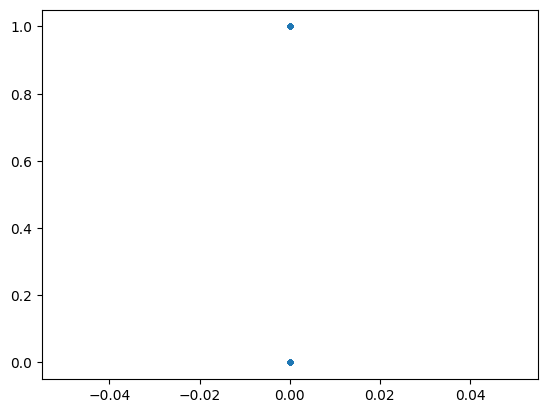

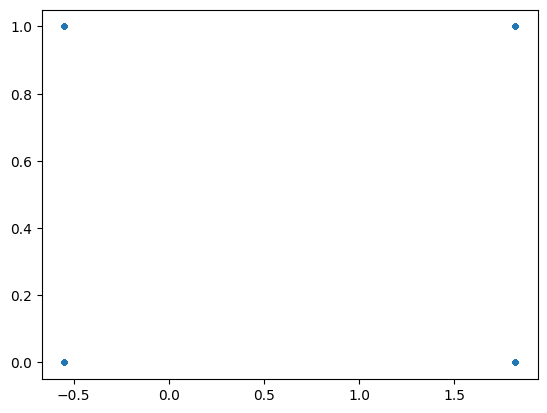

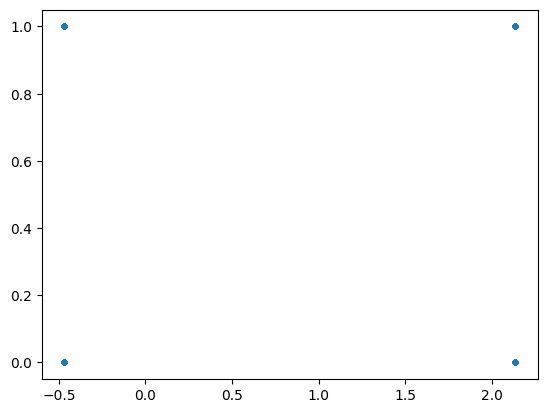

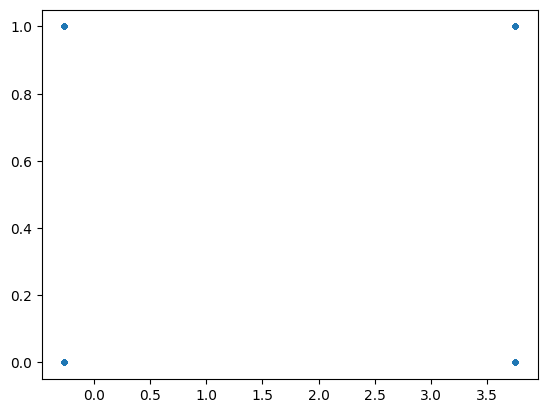

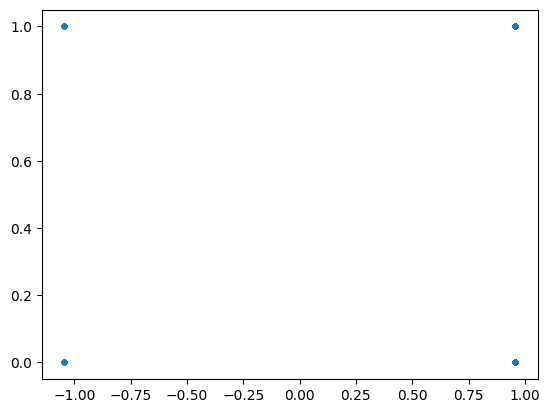

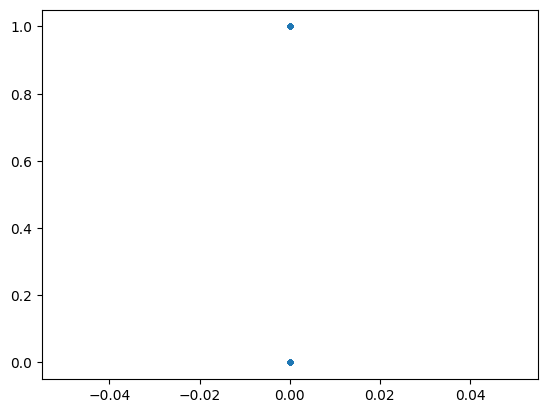

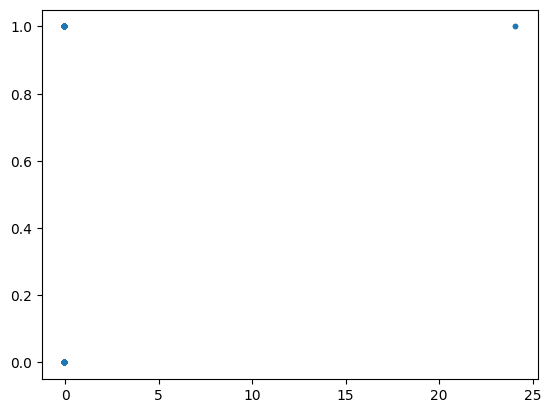

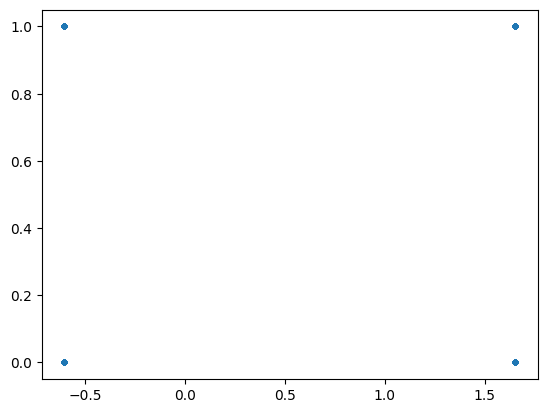

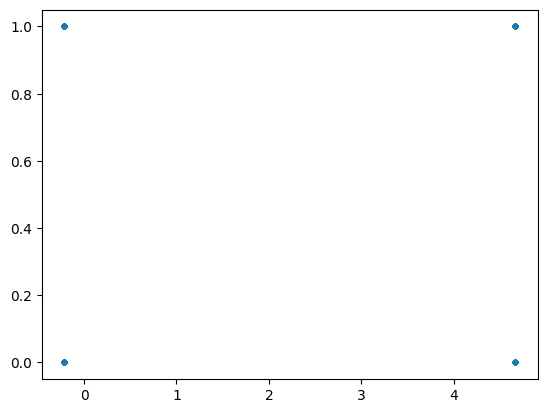

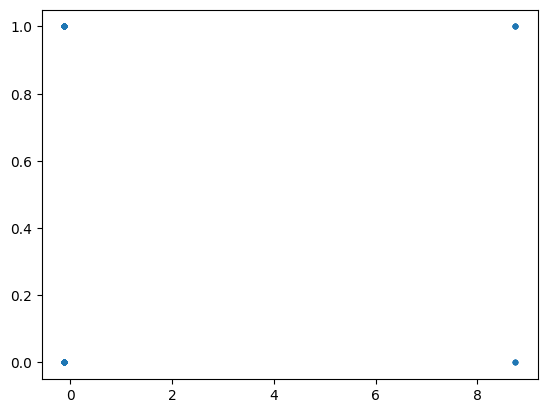

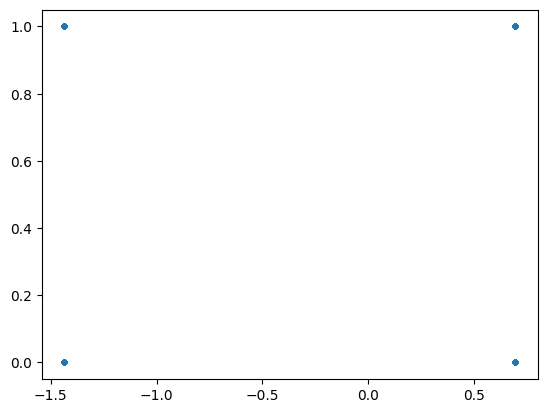

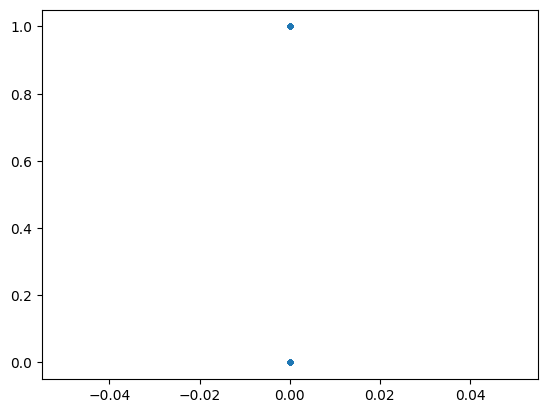

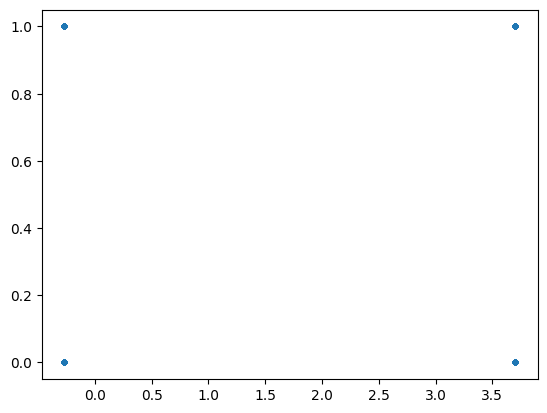

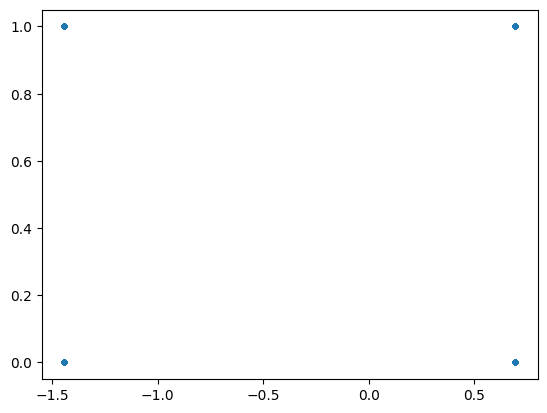

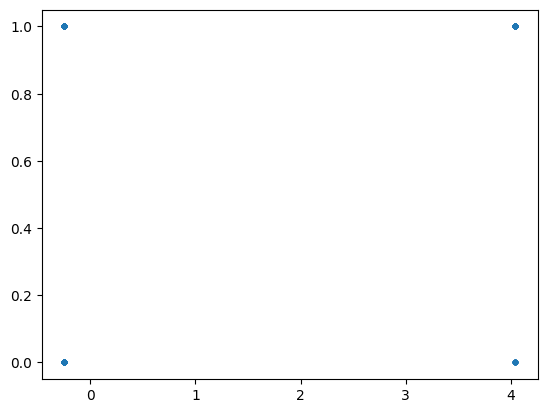

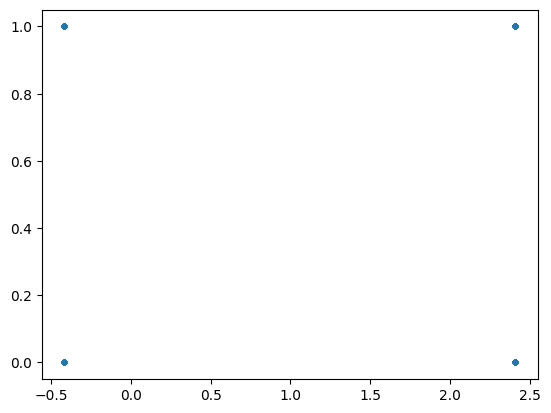

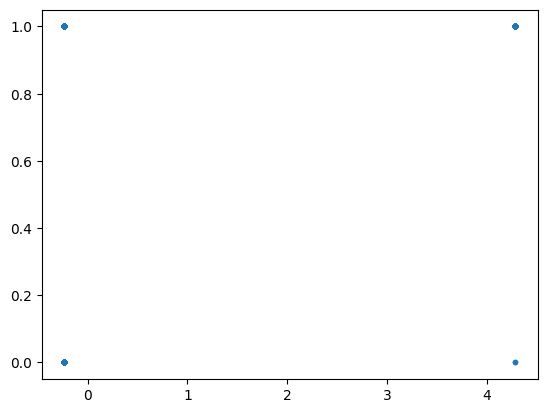

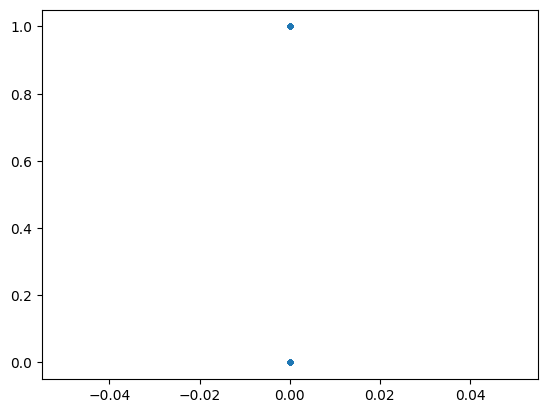

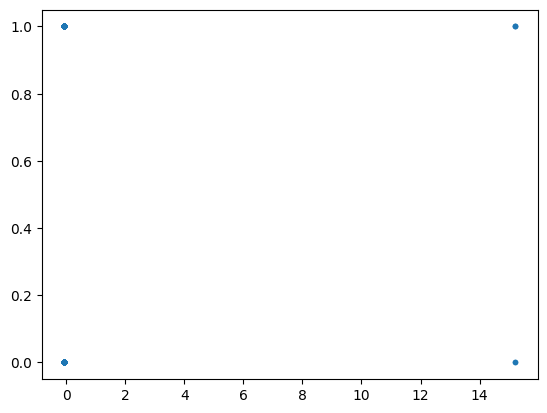

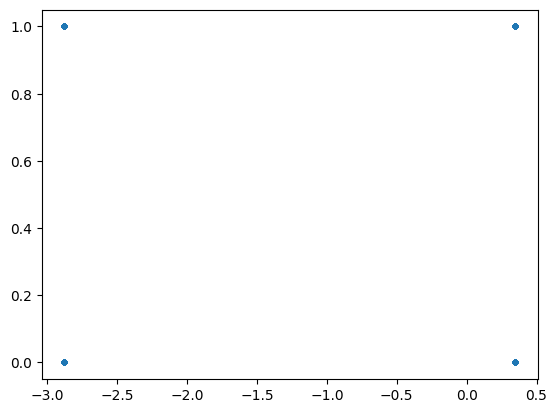

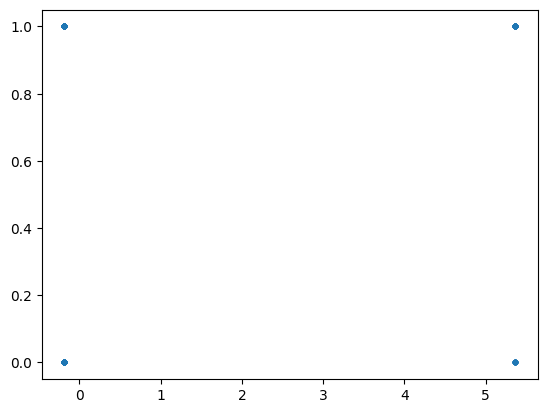

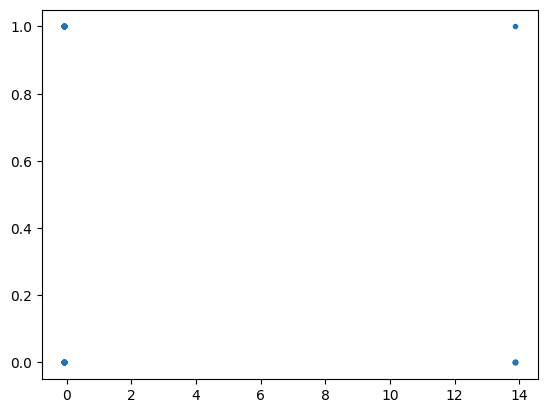

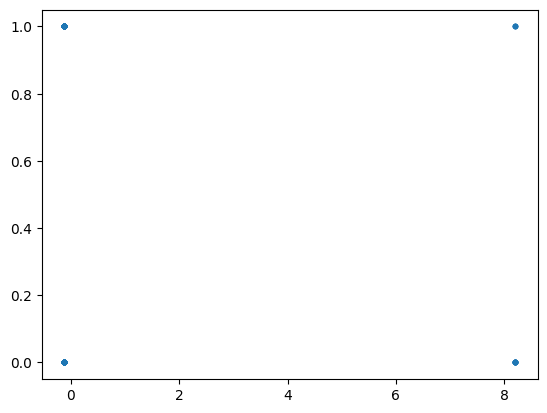

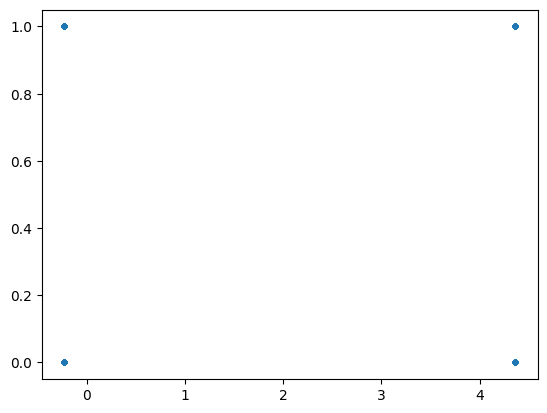

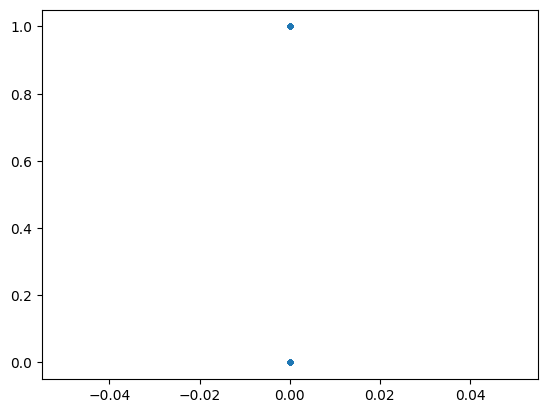

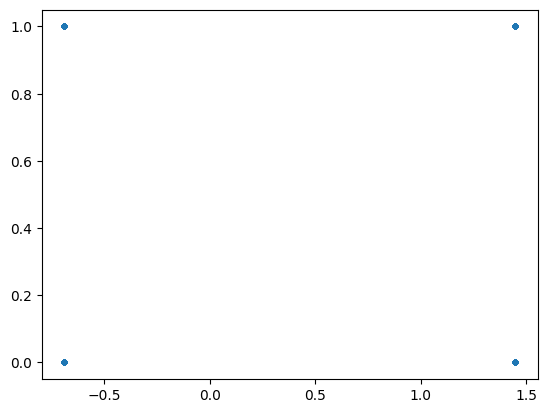

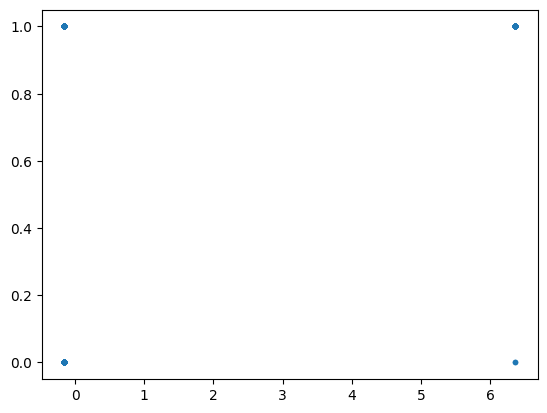

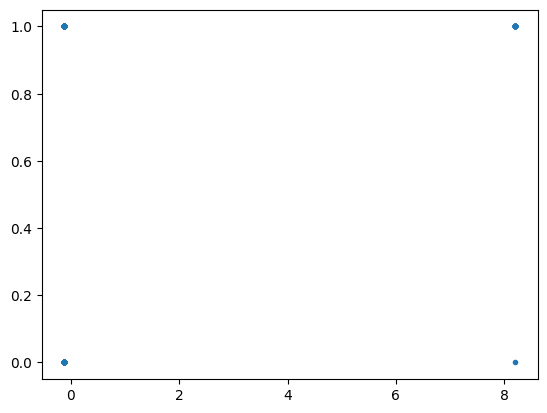

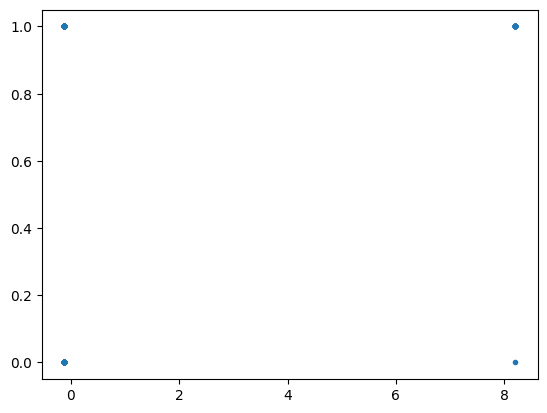

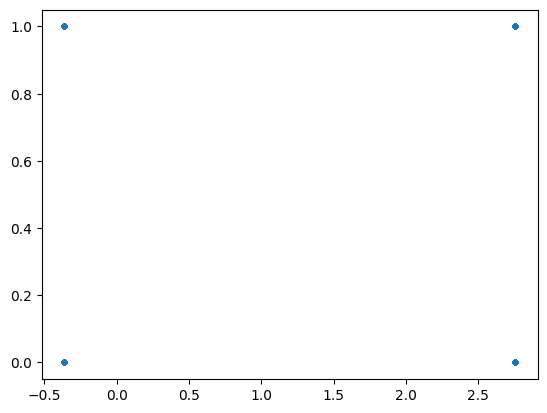

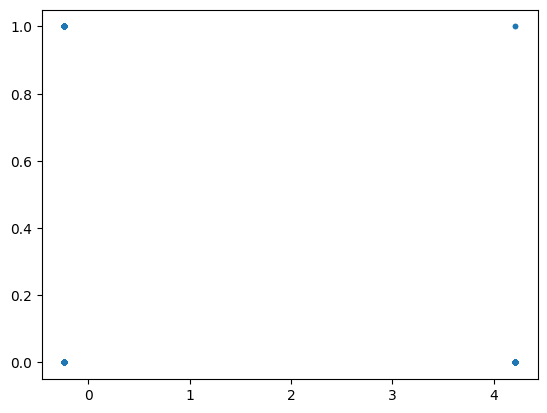

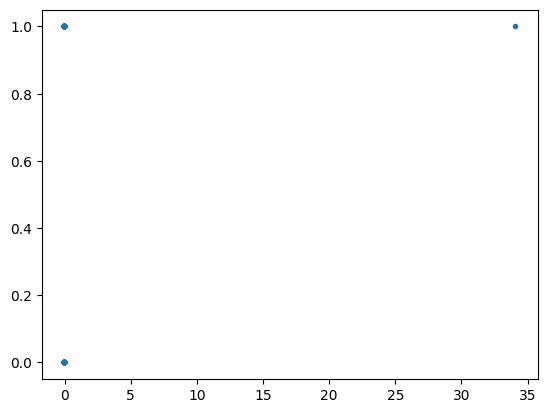

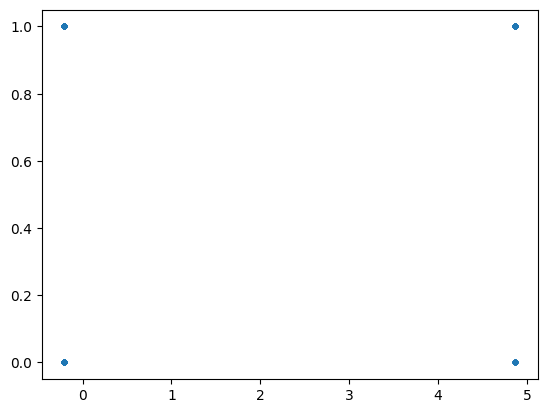

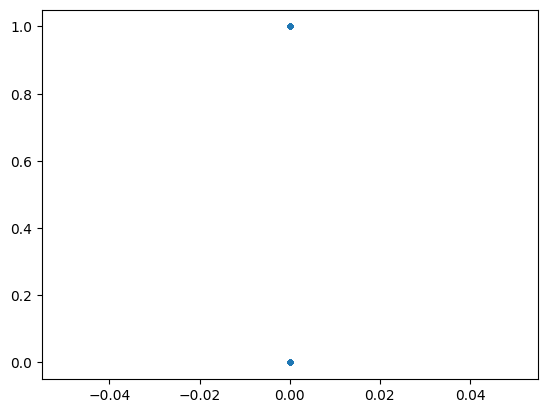

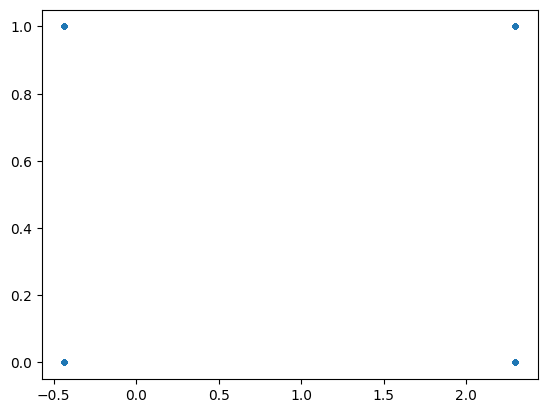

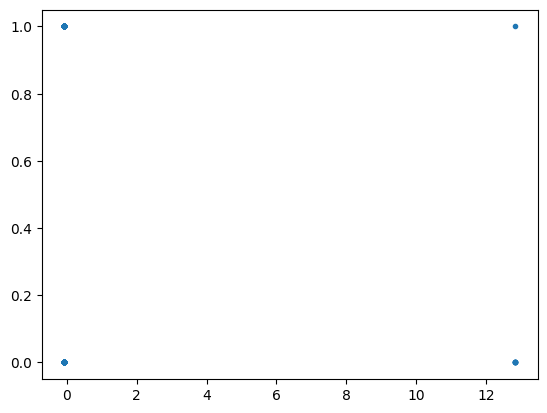

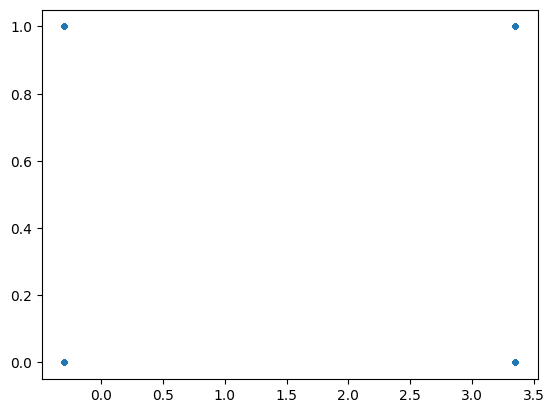

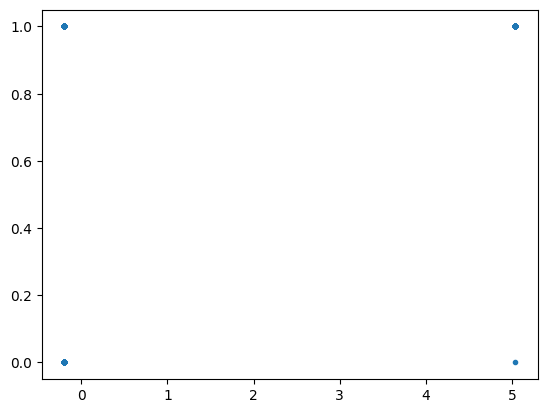

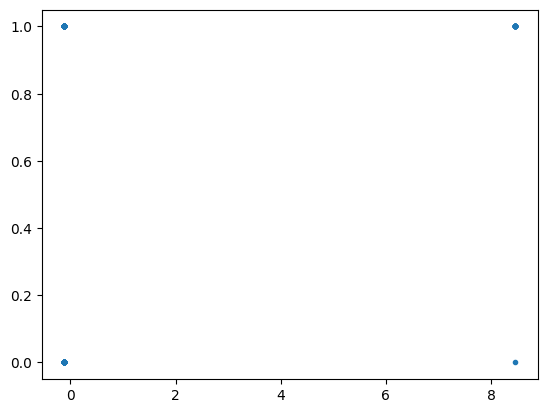

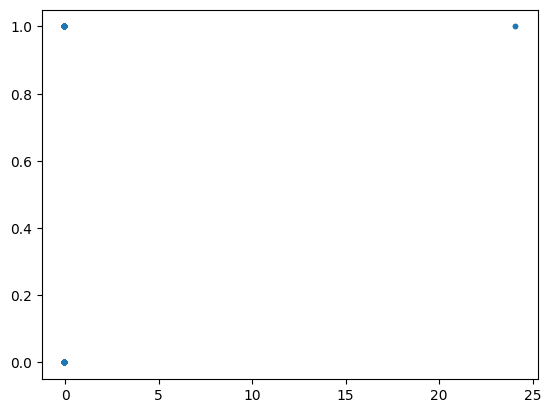

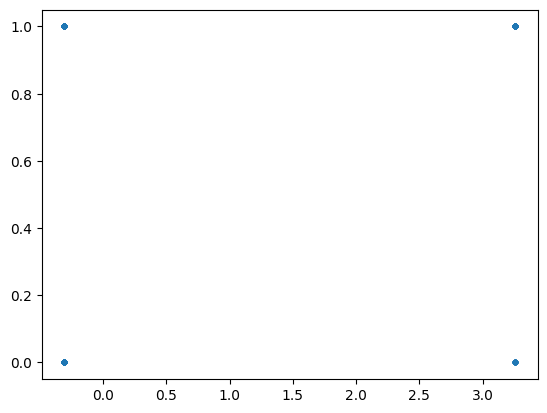

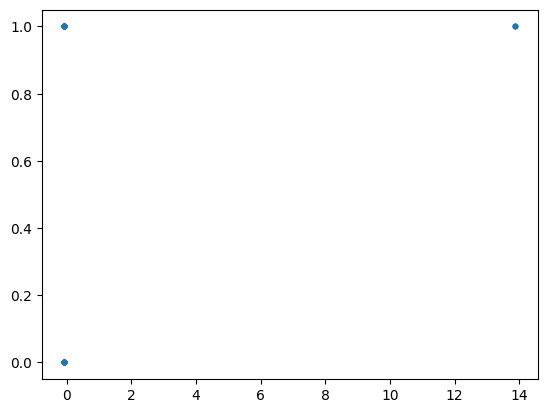

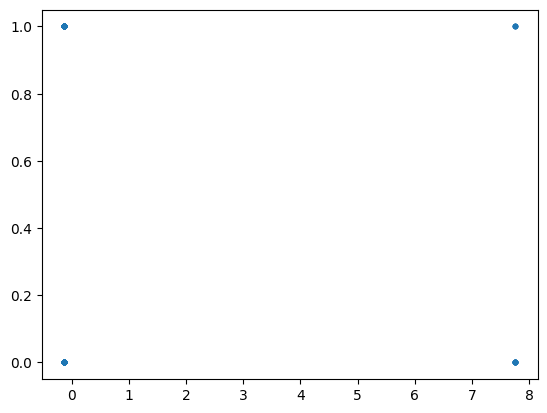

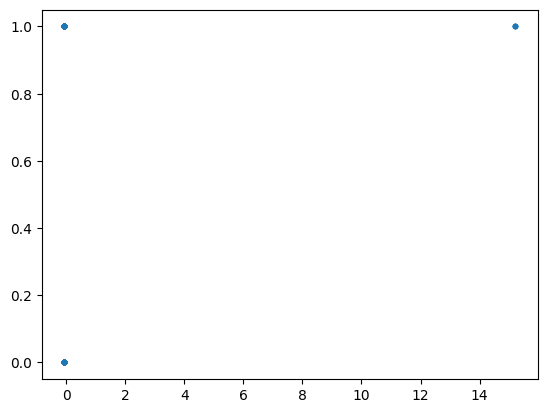

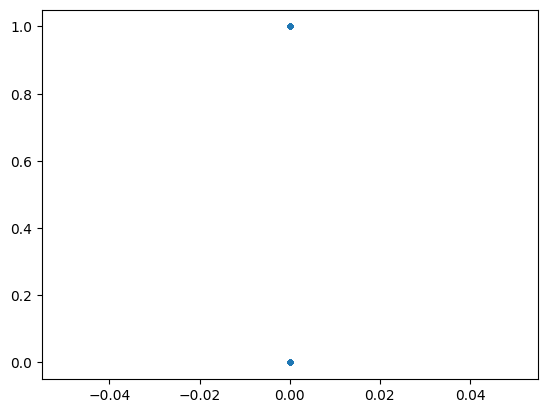

In [59]:
for i in range(X_train_trans.shape[1]):
    plt.plot(X_train_trans[:,i], y_train,'.')
    plt.show()

In [60]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve


KNN : : 0.8970934047905501
LM : : 1.0
SV : : 0.9986875205074921


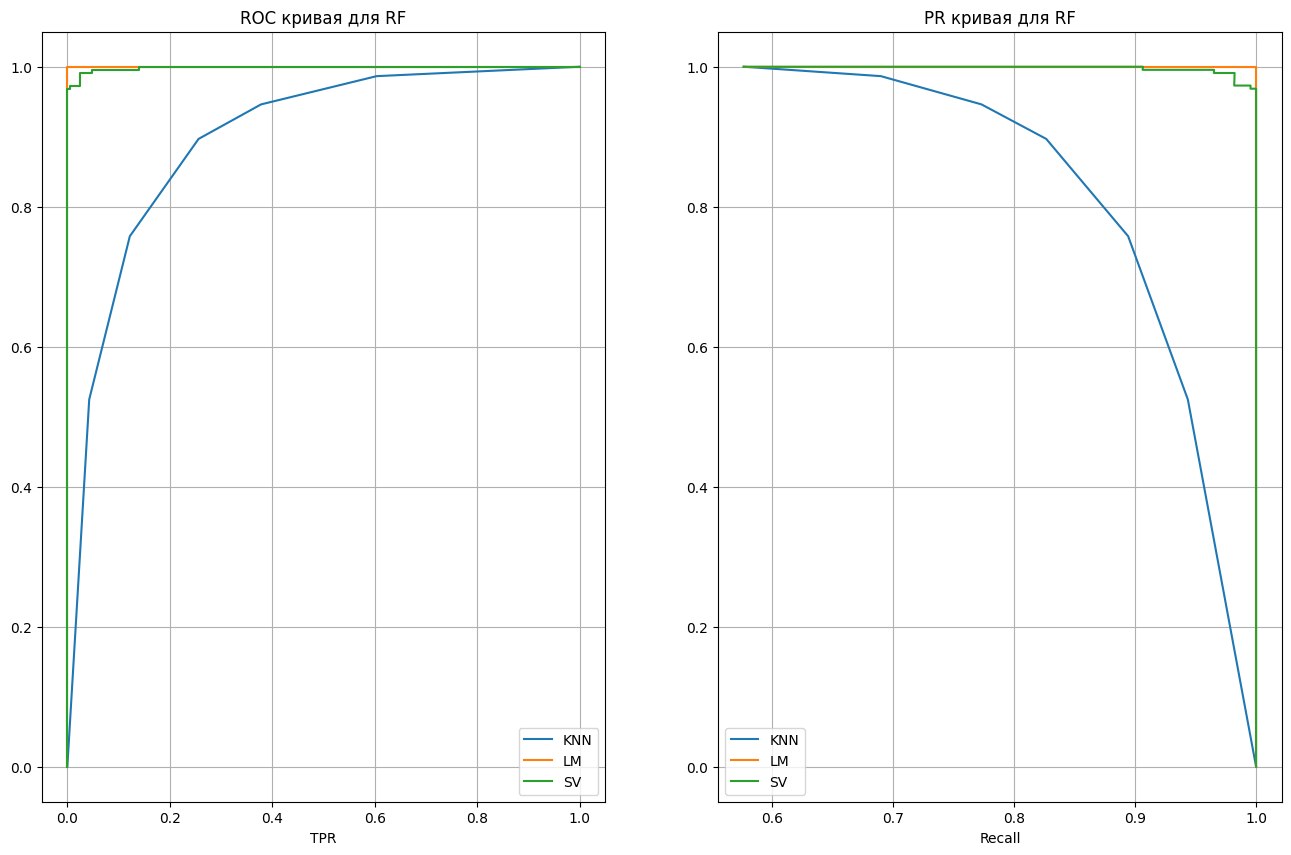

In [61]:
plt.figure(figsize =(16,10))
for i,model in enumerate(list_class["cls"]):
    yp = model.fit(X_train_trans,y_train).predict_proba(X_test_trans)[:,1]
    list_class['metric'][i] = roc_auc_score(y_test,yp)
    p,r,t = roc_curve(y_test,yp)
    plt.subplot(1,2,1)
    plt.plot(p,r,label = cls_[i])
    p,r,t = precision_recall_curve(y_test,yp)
    plt.subplot(1,2,2)
    plt.plot(p,r,label = cls_[i])
    print(cls_[i],": :",list_class['metric'][i])
plt.subplot(1,2,1)
plt.title('ROC кривая для RF')
plt.grid(True)
plt.xlabel('FPR')
plt.xlabel('TPR')
plt.legend()
plt.subplot(1,2,2)
plt.title('PR кривая для RF')
plt.grid(True)
plt.xlabel('Precision')
plt.xlabel('Recall')
plt.legend()
plt.show()


Вывыод:
1. K-Nearest Neighbors (KNN): 0.897
   - Модель K-Nearest Neighbors показала точность примерно 0.897, что означает, что она верно классифицирует около 89.7% образцов в наборе данных.

2. Linear Model (LM): 1.0
   - Линейная модель демонстрирует идеальную точность, равную 1.0. Это означает, что она правильно классифицирует все образцы в наборе данных.

3. Support Vector Machine (SVM): 0.999
   - Модель Support Vector Machine показывает высокую точность, близкую к 0.999, что говорит о правильной классификации примерно 99.9% образцов в наборе данных.

Эти результаты указывают на то, что линейная модель (LM) и модель Support Vector Machine (SVM) демонстрируют очень высокую точность, в то время как модель K-Nearest Neighbors (KNN) имеет немного более низкую точность, но всё равно остается эффективной для задачи классификации данных.
